In [2]:
import os
import sys
import pandas as pd
from scipy.optimize import curve_fit
from IPython.display import clear_output
from matplotlib.gridspec import GridSpec
# Get the path of the current notebook
current_dir = os.path.dirname(os.path.abspath(''))
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))

# Add the desired folder to sys.path
python_folder = os.path.join(current_dir, 'python')
run_folder = os.path.join(parent_dir, 'run')

sys.path.append(python_folder)
sys.path.append(run_folder)

from Imports_cuts import *

# Verification study of a Geant4 implemented MonteCarlo Simulation

The simulation as described in the paper by Bruenner, Colijn and Kesber is a Variance reduced Montecarlo simulation for photon transport trough a Liquid Xenon detector. 
Their simulation is written in python and does not account for all propagation processes such as bremsrahlung.
The paper uses two methods to simulate the photons:

1. **Standard Monte Carlo (MC)**:
   - Simulates particles by propagating them step by step and calculating the probability of scattering at each step.
   - Requires a large number of events to achieve sufficient statistics, particularly for rare low energy interactions within a specified fiducial volume.

2. **Variance Reduction (VR)**:
   - Implements importance sampling by forcing specific events and calculating the probability of these events and applying them as weights.
   - Improves computational efficiency by only simulating relevant events and allows for high statistics in the ROI. 

The simulation has since been implemented in Geant4 and this notebook will verify the implementation of this Geant4 version of the simulation. 
Both the standard and the VR versions of the simulation have been implemented in Geant4 by A.P Colijn.
The Geant4 version applies physical models, such as Compton scattering, Photoelectric effect and bremstrahlung, and allows to filter events based on defined cuts, such as energy thresholds and fiducial volumes. 
The goal is to evaluate the efficiency and accuracy of the VR method compared to the standard MC approach and also compare the Geant4 version to the fully pythonic simulation.

### Geometry
- **InnerCryostat**: radius (r): 655, height (z): 1500, Thickness: 5
- **Liquid Xenon**: radius (r): 650, height (z): 1500
- **Fiducial Volume**: radius (r): 570, height (z): 1340

### Data Description
The data is made up of events and each event can have multiple hits. And each hit is a clustering of small energy deposits around the scatter event. 

A few important data variables on the event level:
- **ndet**: Gives the amount of energy deposits of an event
- **nphot**: Gives the amount of photoelectric absorptions in an event
- **ncompt**: Gives the amount of Compton scatters in an event

A few important data variables on the hit level:
- **r**: The radial distance of the hit.
- **zh**: The z coordinate of the hit. 
- **eh**: The energy deposited in this hit
- **type**: General info about event. (Did bremstrahlung occur? direct gamma? Did a bremstrahlung escape the detector?)

In [2]:
manager = RunManager("/data/xenon/edecleen/master/G4Sim/run/rundb.json")
pd.options.display.max_rows = 100
display(manager.display_all_runs(include_deleted=False))


NameError: name 'RunManager' is not defined

In [3]:

cut_main = lambda data: (
    (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  & 
    (data['ndet'][:, 0] + data['ndet'][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) 
)

# Hit-level cut (for r and zh)
cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -750) & (data['zh'] < 750)

test_nopair = Geant4Analyzer("run_244", first_only=False)
test_pair = Geant4Analyzer("run_245", first_only=False)
test_pair_no_mac = Geant4Analyzer("run_246", first_only=False)
test_nopair.preprocess_data(cut=cut_main, cut_hit=cut_hit_main_no_FV)
test_pair.preprocess_data(cut=cut_main, cut_hit=cut_hit_main_no_FV)
test_pair_no_mac.preprocess_data(cut=cut_main, cut_hit=cut_hit_main_no_FV)

Initialized Geant4Analyzer with run_id=run_247, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250203_110035/fast_0.root']
Loading /data/xenon/edecleen/master/data_ez/20250203_110035/fast_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250203_110035/fast_0.root']
Initialized Geant4Analyzer with run_id=run_245, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250203_105245/std_test_messenger_std_0.root']
Loading /data/xenon/edecleen/master/data_ez/20250203_105245/std_test_messenger_std_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250203_105245/std_test_messenger_std_0.root']
Initialized Geant4Analyzer with run_id=run_246, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250203_105543/std_test_messenger_std_0.root']
Loading /data/xenon/edecleen/master/data_ez/20250203_105543/std_test_messenger_std_0.root
Data loaded from 1 files
Data loaded from ['/data/x

integral Standard= 228.83280442841422
integral nopair= 1960.0
integral nopair_nomax= 2053.0


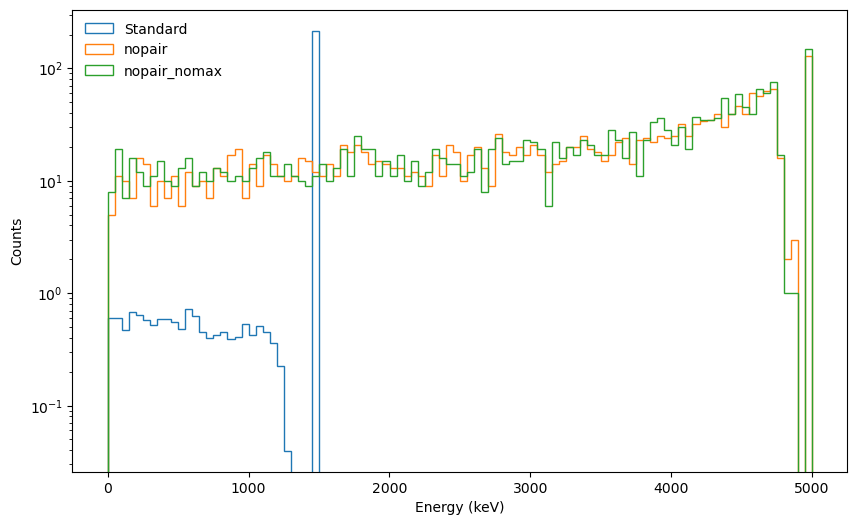

In [4]:

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
test_nopair.plot_histogram('eh', bins=100, ax=ax,label="Standard", show=True, range=(0, 5000 + 1))
test_pair.plot_histogram('eh', bins=100,ax=ax, label="nopair", show=True, range=(0, 5000 + 1))
test_pair_no_mac.plot_histogram('eh', bins=100,ax=ax, label="nopair_nomax", show=True, range=(0, 5000 + 1))
ax.set_yscale('log')

### Simulations used for Figure 1 (1 MeV source)
- "std_no_FV": Standard simulation without a defined fiducial volume
- "std_FV" : Standard simulation with a fiducial volume defined.
- "fast_no_FV" : A fast simulation  without a defined fiducial volume
- "fast_FV" : A fast simulation  with a defined fiducial volume
- "fast_FV_cut" :  A fast simulation  with a defined fiducial volume and a energy cut of 250 KeV


### Cuts used
- "cut_main": Selects events with a single scatter of the main photon (either PE or Compton), a single energy deposit and the photon has not scattered before entering the xenon.
- "cut_hit_main" : Selects hits that occured within the fiducial volume
- "cut_hit_main_no_FV" : Selects all hits within the Xenon volume

In [2]:
# Load the datafiles into the Geant4Analyzer
std_no_FV = Geant4Analyzer("run_02", first_only=False)
std_FV = Geant4Analyzer("run_03", first_only=False)
fast_no_FV = Geant4Analyzer("run_01", first_only=False)
fast_FV = Geant4Analyzer("run_04", first_only=False)
fast_FV_cut = Geant4Analyzer("run_05", first_only=False)

clear_output()

In [22]:
# event level cut
cut_main = lambda data: (
    (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  & 
    (data['ndet'][:, 0] + data['ndet'][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) 
)

# Hit-level cut (for r and zh)
cut_hit_main = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670)
cut_hit_main_no_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -750) & (data['zh'] < 750)

In [18]:
# apply the cuts
std_no_FV.preprocess_data(cut=cut_main, cut_hit=cut_hit_main_no_FV)
std_FV.preprocess_data(cut=cut_main, cut_hit=cut_hit_main)
fast_no_FV.preprocess_data(cut=cut_main, cut_hit=cut_hit_main_no_FV)
fast_FV.preprocess_data(cut=cut_main, cut_hit=cut_hit_main)
fast_FV_cut.preprocess_data(cut=cut_main, cut_hit=cut_hit_main)

### Figure 1
In figure 1 the energy spectra of the fast VR simulation and the standard simulation are compared to eachother. 
We compare a fast and standard simulation with a defined FV and also simulations without a defined FV, lastly a fast simulation with a energy cutoff at 250 KeV is used.

### Observations
- The standard simulation has hits with E > 800 KeV, this is higher than the compton scatter energy formula allows and needs to be investigated further.
- In this Figure the cut on "ndet" is equal to 1. In the VR simulation this cuts out no events since we force this to be true. 
However in the standard simulation there are events with multiple detected energy deposits. 
These "extra" deposits are either caused by inproper clustering or Bremstrahlung carrying away some energy from the hit and depositing it elsewhere. If the "ndet" cut is not applied then some of the higher energy hits will be split into multiple lower energy hits. This also 

### Observations
- The standard simulation has hits with \(E > 800 \, \text{keV}\), which is higher than the Compton scatter energy formula allows and needs to be investigated further.
- In this figure, the cut on "ndet" is equal to 1. In the VR simulation, this cuts out no events since we force this to be true.  
However, in the standard simulation, there are events with multiple detected energy deposits but only a single PE or Compton scatter. These "extra" deposits are either caused by:

**Improper Clustering**
   - A single hit is split into multiple hits.
   - Suboptimal clustering algorithm parameters.

**Bremsstrahlung**
   - Electrons emit Bremsstrahlung photons, carrying away energy from the initial hit.
   - This causes higher energy hits to be split into multiple lower energy hits. These events get cut out by setting "ndet" = 1.

**Characteristic X-ray**
   - It is possible a photon scatters on a electron,  

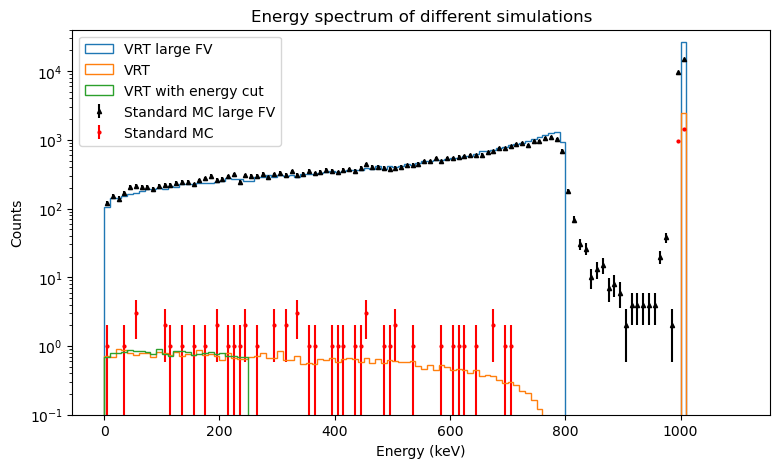

In [22]:
data_dict = {
    'Standard MC large FV': std_no_FV,
    'Standard MC': std_FV,
    'VRT large FV': fast_no_FV,
    'VRT': fast_FV,
    'VRT with energy cut': fast_FV_cut
}

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
plot_range = (0, 1100)
n_bins = 110

for key, data in data_dict.items():
    # For "Standard MC large FV": black triangles with error bars
    if key == 'Standard MC large FV':
        # 1) Compute histogram manually
        counts, bin_edges = np.histogram(data.data['eh'], bins=n_bins, range=plot_range)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        # 2) Error bars (assuming Poisson, sqrt of counts)
        errors = np.sqrt(counts)
        # 3) Plot
        ax.errorbar(
            bin_centers, counts, yerr=errors,
            fmt='^',     # triangle marker
            color='black',
            markersize=3,
            label=key
        )
    # For "Standard MC": red dots with error bars
    elif key == 'Standard MC':
        counts, bin_edges = np.histogram(data.data['eh'], bins=n_bins, range=plot_range)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        errors = np.sqrt(counts)
        ax.errorbar(
            bin_centers, counts, yerr=errors,
            fmt='o',     # circular marker
            color='red',
            markersize=2,
            label=key
        )
    
    # For all others, just use the existing histogram plot
    else:
        data.plot_histogram(
            'eh', ax=ax,
            bins=n_bins, range=plot_range,
            label=key,
            show=False
        )

# Format the axes
ax.set_title('Energy spectrum of different simulations')
ax.set_yscale('log')
ax.set_ylim(0.1, 4e4)
ax.legend(loc='upper left')

clear_output()
plt.show()

### Figure 2
In figure 2 the spatial distribution of the hits are plotted. On the x axis we are plotting the squared radial distance to better vizualse the difference between distances.
We compare a fast simulation that only generated hits within the FV and with $E<E_max$ to a standard simulation with a FV and energy cut applied to it.

### Simulations used for Figure 1 (1 MeV source)
- "std_no_FV": Standard simulation without a defined fiducial volume
- "fast_FV_cut" :  A fast simulation  with a defined fiducial volume and a energy cut of 250 KeV

### Cuts used
- "cut_main": Selects events with a single scatter of the main photon (either PE or Compton), a single energy deposit and the photon has not scattered before entering the xenon.
- "cut_hit_main_no_FV" : Selects all hits within the Xenon volume

### Observations
- Good visualisation of the increased statistics wihtin the ROI.
- The image is visually comparable to the one in the Paper.

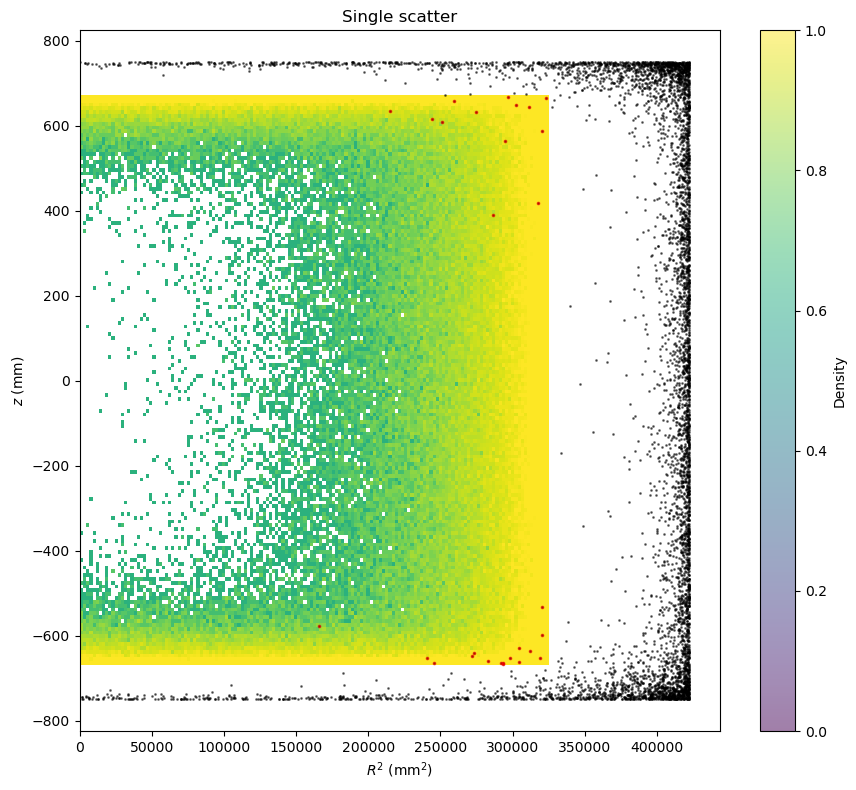

In [5]:
# plot the spatial distribution of the events
cut_hit_no_FV_Ecut = lambda data: (data['r'] < 650 ) & (data['zh'] > -750) & (data['zh'] < 750) & (data['eh'] < 250)

std_no_FV.preprocess_data(cut=cut_main, cut_hit=cut_hit_no_FV_Ecut)
fast_FV_cut.preprocess_data(cut=cut_main, cut_hit=cut_hit_no_FV_Ecut)

spatial_distribution(std_no_FV, fast_FV_cut)


### Figure 3 & 4
In figure 3 the relative difference between the average number of interactions for 10 simulations with $N_\gamma$ and the reference simulation with $N_\infty$. It shows the convergence as a function of the amount of simulated events.
Figure 4 is a visualisation of these 10 simulations for a specific $N_\gamma$, it illustrates how the VR simulation converges more efficiently to a certain value.

### Simulations used for Figure 3 & 4 (1.5 MeV source)
- "run_99": Standard simulation with $N_\infty = 10^9$, we use this as a reference MC
- "run_121": Standard Simulation with larger clustering and brehmstralung photons killed on creation and energt added back to the electron.
- "runs" :  We run the simulation 10 times for increasing $N_\gamma$ for both the fast and the standard simulation.

### Cuts used
- "cut_main": Selects events with a single scatter of the main photon (either PE or Compton), a single energy deposit and the photon has not scattered before entering the xenon.
- "cut_hit_FV_energy" : Selects all hits within the FV and hits below $E_{max} = 250 KeV$ 

### Observations
- The fast and standard simulation converge to different values. The fast simulation predicts more events in the ROI than the standard simulation. A normal simulation with high statistics converge to a fraction of 3.37e-5 within the specified cuts while the fast simulation converges to 3.65e-5. To see if this descrepancy is caused by improper clustering and brehmstralung photons carrying away some energy and thus making a single deposit (ndet=1) into a event with multiple deposits I ran a high statistics simulation where the clustering threshhold is twice as large and brehmstrahlung photons are instantly killed and the energy is added back into the electron. This altered simulation yielded a fraction of 3.4391e-05 within the cut, which is only marginally closer to the fraction of the fast simulation.

- It could also be caused by photons generated trough characteristic X-rays caused by de-exitation (electrons switching to a lower shell and emitting a photon)

- Another potential cause of the descrepancy could be the fact that the normal simulation has compton scatters with higher recoil energies than the compton scatter formula would allow, thus having more events with higher energies. 

In [53]:
# NORMAL CLUSTERING AND NORMAL BREM TRACKING

# Define a hit cut within the FV and with an energy cut
cut_hit_FV_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 250)
cut_hit_main_FV_no_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 2500)

# caculate the amount of points in the dataset that pass the cuts
total_points = count_points_in_cut(dataset_id="run_99", num_jobs=100, cut_main=cut_main, cut_hit=cut_hit_FV_energy)

# Final total points
print(f"Total points across all 100 jobs: {total_points}")

N_ref = total_points/10e9
""
"Total points across all 100 jobs with Energy cut 250KeV: 33712"
"Fraction of points beneath the energy cut: 0,000033712 or 3.37e-5"

"Job 98: 19925.0 points found. Total so far: 1949469.0"
"Total points across all 100 jobs without Energy cut 250KeV: 1989223.0"
"Fraction of points in the cut without energy cut: 0,001989223"

Processing job 1 / 100...
Initialized Geant4Analyzer with run_id=run_99, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20241120_114819/std_25.root']
Loading /data/xenon/edecleen/master/data_ez/20241120_114819/std_25.root


Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20241120_114819/std_25.root']
Job 1: 358.0 points found. Total so far: 358.0
Processing job 2 / 100...
Initialized Geant4Analyzer with run_id=run_99, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20241120_114819/std_30.root']
Loading /data/xenon/edecleen/master/data_ez/20241120_114819/std_30.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20241120_114819/std_30.root']
Job 2: 352.0 points found. Total so far: 710.0
Processing job 3 / 100...
Initialized Geant4Analyzer with run_id=run_99, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20241120_114819/std_98.root']
Loading /data/xenon/edecleen/master/data_ez/20241120_114819/std_98.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20241120_114819/std_98.root']
Job 3: 309.0 points found. Total so far: 1019.0
Processing job 4 / 100...
Initialized Geant4Analyzer

KeyboardInterrupt: 

In [21]:
# Run configurations
N_values = [10, 100, 1000, 10000, 100000, 1000000, 10000000]

# VRT with pairprod. Normal standard
runs = {
    "fast": {
        10: "run_209", 100: "run_210", 1000: "run_212", 10000: "run_213", 
        100000: "run_214", 1000000: "run_215", 10000000: "run_216"
    },
    "standard": {
        10: "run_100", 100: "run_101", 1000: "run_102", 10000: "run_103",
        100000: "run_104", 1000000: "run_105", 10000000: "run_106"
    }
}

# VRT without pairprod. Normal standard
runs_original = {
    "fast": {
        10: "run_228", 100: "run_229", 1000: "run_230", 10000: "run_231", 
        100000: "run_232", 1000000: "run_233", 10000000: "run_234"
    },
    "standard": {
        10: "run_100", 100: "run_101", 1000: "run_102", 10000: "run_103",
        100000: "run_104", 1000000: "run_105", 10000000: "run_106"
    }
}

cut_hit_main_FV_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 250)
cut_hit_main_FV_no_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 2500)

# Process both fast and standard simulations
# N_BG_fast = find_counts(runs["fast"], cut_main, cut_hit_main_FV_no_energy, sim_type="fast")
# N_BG_std = find_counts(runs["standard"], cut_main, cut_hit_main_FV_no_energy, sim_type="standard")

N_BG_fast_original = find_counts(runs_original["fast"], cut_main, cut_hit_main_FV_no_energy, sim_type="fast")
N_BG_std_original = find_counts(runs_original["standard"], cut_main, cut_hit_main_FV_no_energy, sim_type="standard")
clear_output()

10000
100000
1000000
10000000


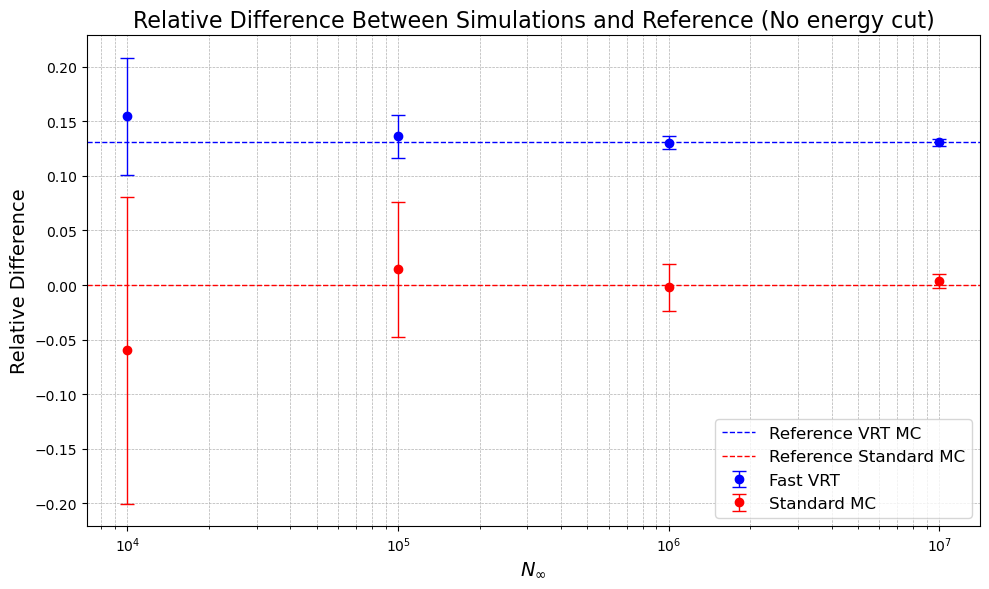

In [24]:
# Figure 3 ORIGINAL FAST SIM
N_ref = 0.001989223
NBG_over_Nref_fast = []
NBG_over_Nref_std = []
errors_fast = []
errors_std = []

for N in N_values[-4:]:  # Adjust number of points if needed
    if len(N_BG_fast_original[N]) == 0 or len(N_BG_std_original[N]) == 0:
        print(f"Skipping N={N} due to empty data.")
        continue
    print(N)
    # Normalize N_BG by N_inf
    mean_fast = np.mean(N_BG_fast_original[N])
    mean_std = np.mean(N_BG_std_original[N])
    normalized_fast = (mean_fast - N_ref * N) / (N_ref * N)
    normalized_std = (mean_std - N_ref * N) / (N_ref * N)
 
    # Calculate errors (standard deviation of the counts)
    error_fast = np.std(N_BG_fast_original[N]) / (N_ref * N)
    error_std = np.std(N_BG_std_original[N]) / (N_ref * N)

    NBG_over_Nref_fast.append(normalized_fast)
    NBG_over_Nref_std.append(normalized_std)
    errors_fast.append(error_fast)
    errors_std.append(error_std)

# Convert to numpy arrays
NBG_over_Nref_fast = np.array(NBG_over_Nref_fast)
NBG_over_Nref_std = np.array(NBG_over_Nref_std)
errors_fast = np.array(errors_fast)
errors_std = np.array(errors_std)

# Plot the data
plt.figure(figsize=(10, 6))
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_fast,
    yerr=errors_fast,
    fmt='bo',
    label="Fast VRT",
    capsize=5,
    capthick=1,
    elinewidth=1,
)
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_std,
    yerr=errors_std,
    fmt='ro',
    label="Standard MC",
    capsize=5,
    capthick=1,
    elinewidth=1,
)

# Customize plot
plt.xscale('log')
plt.axhline(y= NBG_over_Nref_fast[-1], color='blue', linestyle='--', linewidth=1, label="Reference VRT MC")
plt.axhline(y= 0, color='red', linestyle='--', linewidth=1, label="Reference Standard MC")
plt.xlabel(r'$N_{\infty}$', fontsize=14)
plt.ylabel(r'Relative Difference', fontsize=14)
plt.title('Relative Difference Between Simulations and Reference (No energy cut)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

10000
100000
1000000
10000000


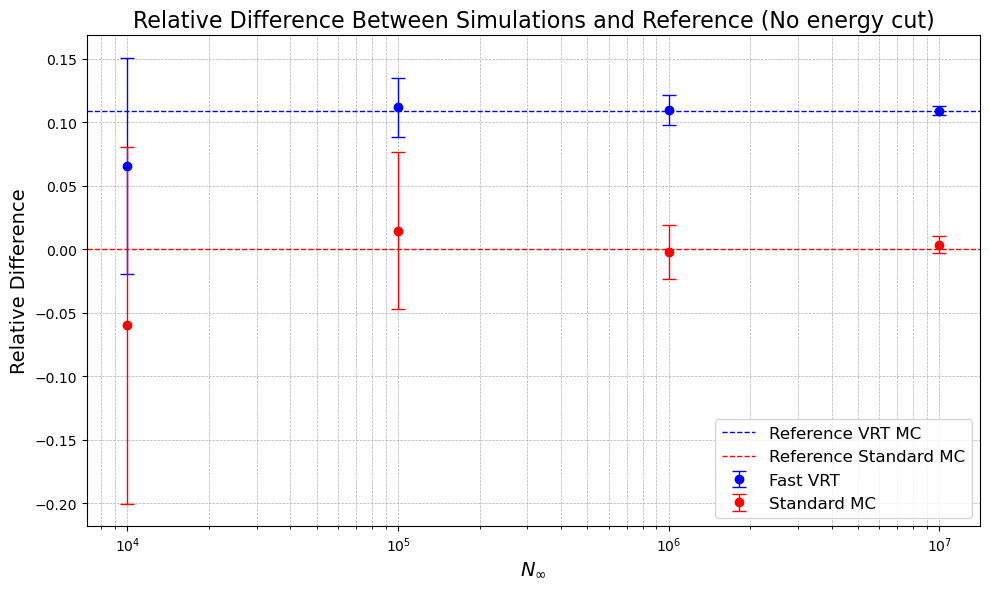

In [38]:
# Figure 3
N_ref = 0.001989223
NBG_over_Nref_fast = []
NBG_over_Nref_std = []
errors_fast = []
errors_std = []

for N in N_values[-4:]:  # Adjust number of points if needed
    if len(N_BG_fast[N]) == 0 or len(N_BG_std[N]) == 0:
        print(f"Skipping N={N} due to empty data.")
        continue
    print(N)
    # Normalize N_BG by N_inf
    mean_fast = np.mean(N_BG_fast[N])
    mean_std = np.mean(N_BG_std[N])
    normalized_fast = (mean_fast - N_ref * N) / (N_ref * N)
    normalized_std = (mean_std - N_ref * N) / (N_ref * N)
 
    # Calculate errors (standard deviation of the counts)
    error_fast = np.std(N_BG_fast[N]) / (N_ref * N)
    error_std = np.std(N_BG_std[N]) / (N_ref * N)

    NBG_over_Nref_fast.append(normalized_fast)
    NBG_over_Nref_std.append(normalized_std)
    errors_fast.append(error_fast)
    errors_std.append(error_std)

# Convert to numpy arrays
NBG_over_Nref_fast = np.array(NBG_over_Nref_fast)
NBG_over_Nref_std = np.array(NBG_over_Nref_std)
errors_fast = np.array(errors_fast)
errors_std = np.array(errors_std)

# Plot the data
plt.figure(figsize=(10, 6))
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_fast,
    yerr=errors_fast,
    fmt='bo',
    label="Fast VRT",
    capsize=5,
    capthick=1,
    elinewidth=1,
)
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_std,
    yerr=errors_std,
    fmt='ro',
    label="Standard MC",
    capsize=5,
    capthick=1,
    elinewidth=1,
)

# Customize plot
plt.xscale('log')
plt.axhline(y= NBG_over_Nref_fast[-1], color='blue', linestyle='--', linewidth=1, label="Reference VRT MC")
plt.axhline(y= 0, color='red', linestyle='--', linewidth=1, label="Reference Standard MC")
plt.xlabel(r'$N_{\infty}$', fontsize=14)
plt.ylabel(r'Relative Difference', fontsize=14)
plt.title('Relative Difference Between Simulations and Reference (No energy cut)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [3]:
# Run configurations
N_values = [10, 100, 1000, 10000, 100000, 1000000, 10000000]
# event level cut

cut_main = lambda data: (
    (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  & 
    (data['ndet'][:, 0] + data['ndet'][:, 1] == 1) &
    (ak.values_astype(data['type'], int) & 3 == 1) 
)

# VRT with pairprod. Normal standard
runs_no_brem = {
    "fast": {
        10: "run_209", 100: "run_210", 1000: "run_212", 10000: "run_213", 
        100000: "run_214", 1000000: "run_215", 10000000: "run_216"
    },
    "standard": {
        10: "run_217", 100: "run_218", 1000: "run_219", 10000: "run_220",
        100000: "run_221", 1000000: "run_222", 10000000: "run_223"
    }
}

cut_hit_main_FV_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 250)
cut_hit_main_FV_no_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 2500)


# Process both fast and standard simulations
N_BG_fast_nobrem = find_counts(runs_no_brem["fast"], cut_main, cut_hit_main_FV_no_energy, sim_type="fast")
N_BG_std_nobrem = find_counts(runs_no_brem["standard"], cut_main, cut_hit_main_FV_no_energy, sim_type="standard")
clear_output()

10000
100000
1000000
10000000


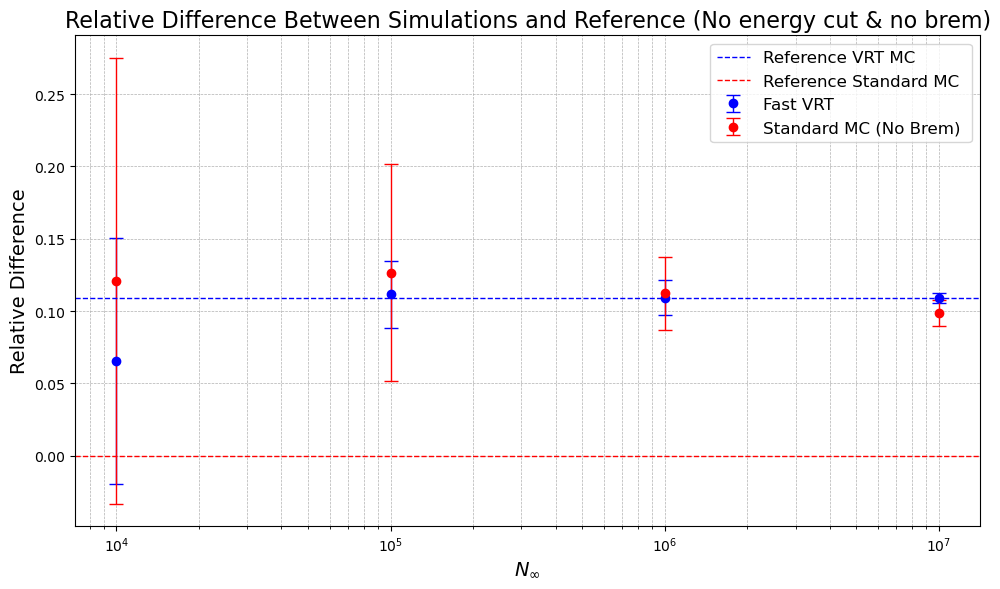

In [6]:
# Figure 3
N_ref = 0.001989223
NBG_over_Nref_fast = []
NBG_over_Nref_std = []
errors_fast = []
errors_std = []

for N in N_values[-4:]:  # Adjust number of points if needed
    if len(N_BG_fast_nobrem[N]) == 0 or len(N_BG_std_nobrem[N]) == 0:
        print(f"Skipping N={N} due to empty data.")
        continue
    print(N)
    # Normalize N_BG by N_inf
    mean_fast = np.mean(N_BG_fast_nobrem[N])
    mean_std = np.mean(N_BG_std_nobrem[N])
    normalized_fast = (mean_fast - N_ref * N) / (N_ref * N)
    normalized_std = (mean_std - N_ref * N) / (N_ref * N)
 
    # Calculate errors (standard deviation of the counts)
    error_fast = np.std(N_BG_fast_nobrem[N]) / (N_ref * N)
    error_std = np.std(N_BG_std_nobrem[N]) / (N_ref * N)

    NBG_over_Nref_fast.append(normalized_fast)
    NBG_over_Nref_std.append(normalized_std)
    errors_fast.append(error_fast)
    errors_std.append(error_std)

# Convert to numpy arrays
NBG_over_Nref_fast = np.array(NBG_over_Nref_fast)
NBG_over_Nref_std = np.array(NBG_over_Nref_std)
errors_fast = np.array(errors_fast)
errors_std = np.array(errors_std)

# Plot the data
plt.figure(figsize=(10, 6))
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_fast,
    yerr=errors_fast,
    fmt='bo',
    label="Fast VRT",
    capsize=5,
    capthick=1,
    elinewidth=1,
)
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_std,
    yerr=errors_std,
    fmt='ro',
    label="Standard MC (No Brem)",
    capsize=5,
    capthick=1,
    elinewidth=1,
)

# Customize plot
plt.xscale('log')
plt.axhline(y= NBG_over_Nref_fast[-1], color='blue', linestyle='--', linewidth=1, label="Reference VRT MC")
plt.axhline(y= 0, color='red', linestyle='--', linewidth=1, label="Reference Standard MC ")
plt.xlabel(r'$N_{\infty}$', fontsize=14)
plt.ylabel(r'Relative Difference', fontsize=14)
plt.title('Relative Difference Between Simulations and Reference (No energy cut & no brem)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

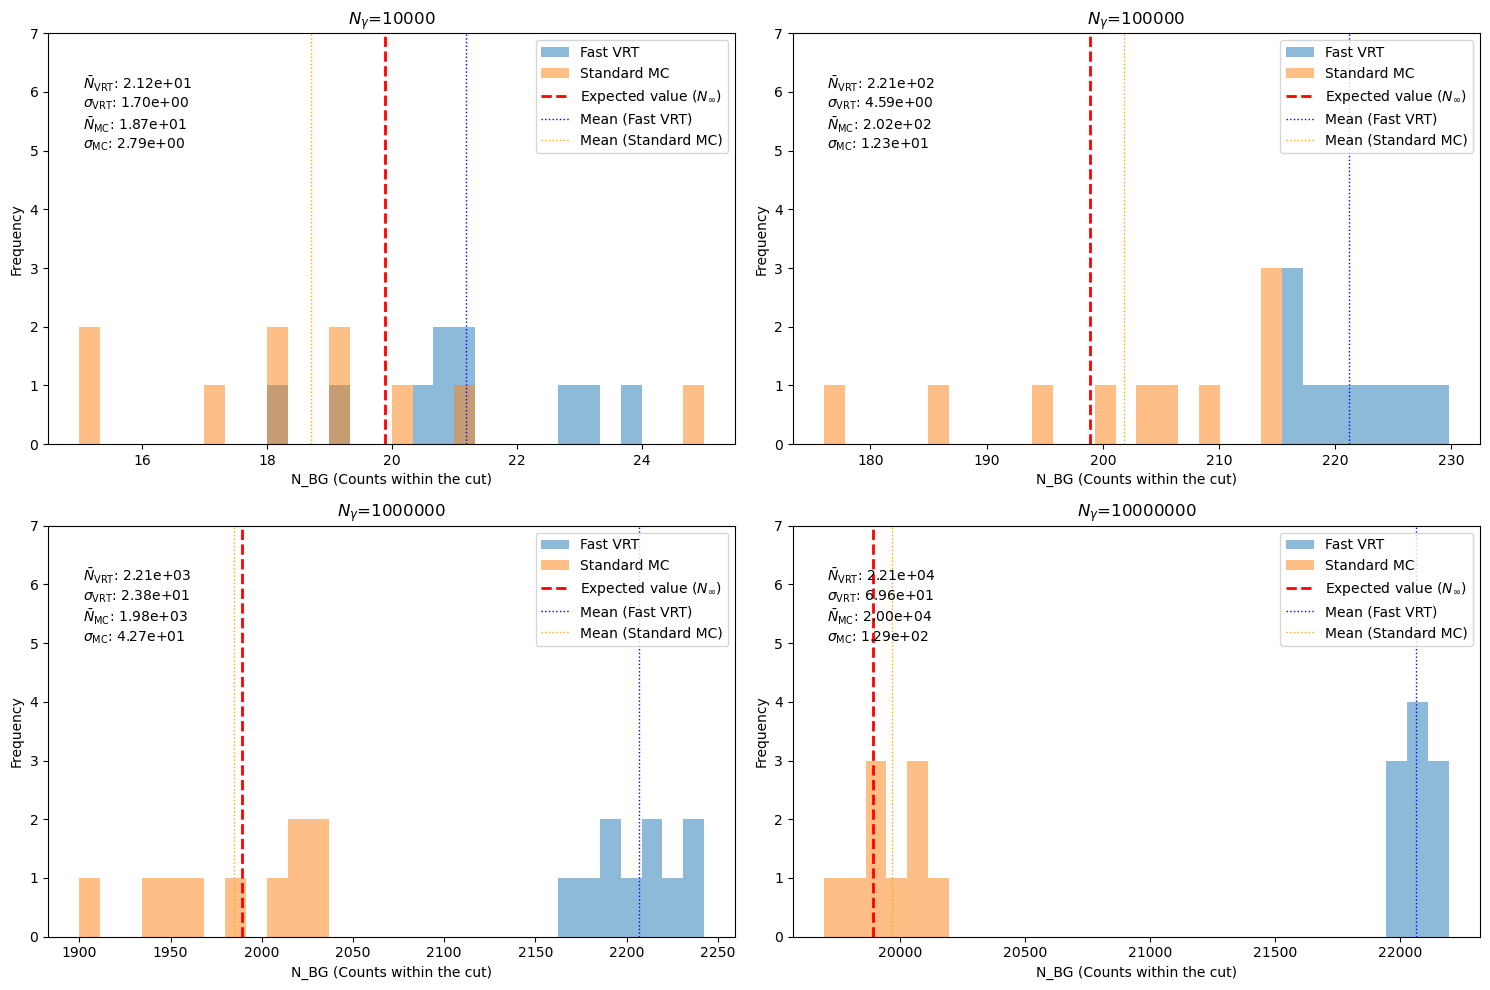

In [42]:
N_ref = 0.001989223
# Filter N_values based on the threshold

# Ensure no more than 4 plots (for a 2x2 grid)
filtered_N_values =  [10000, 100000, 1000000, 10000000]

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make it easier to iterate

for idx, N in enumerate(filtered_N_values):
    ax = axes[idx]

    # Compute statistics
    Nbar_VRT = np.mean(N_BG_fast[N])
    Nbar_MC = np.mean(N_BG_std[N])
    sigma_VRT = np.std(N_BG_fast[N])
    sigma_MC = np.std(N_BG_std[N])
    range_ = (np.min(N_BG_fast[N] + N_BG_std[N]), np.max(N_BG_fast[N] + N_BG_std[N]))

    # Plot histograms
    ax.hist(N_BG_fast[N], bins=30, range=range_, alpha=0.5, label="Fast VRT")
    ax.hist(N_BG_std[N], bins=30, range=range_, alpha=0.5, label="Standard MC")

    # Add vertical lines
    vline_value = N_ref * N
    ax.axvline(x=vline_value, color='r', linestyle='dashed', linewidth=2, label="Expected value ($N_{\infty}$)")
    ax.axvline(x=Nbar_VRT, color='blue', linestyle='dotted', linewidth=1, label="Mean (Fast VRT)")
    ax.axvline(x=Nbar_MC, color='orange', linestyle='dotted', linewidth=1, label="Mean (Standard MC)")

    

    # Add labels and title
    ax.set_xlabel("N_BG (Counts within the cut)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"$N_\gamma$={N} (No energy cut)")
    #set the y range
    ax.set_ylim(0, 7)
    # Add text annotations
    ax.text(0.05, 0.9,
            f"$\\bar{{N}}_{{\\mathrm{{VRT}}}}$: {Nbar_VRT:.2e}\n"
            f"$\\sigma_{{\\mathrm{{VRT}}}}$: {sigma_VRT:.2e}\n"
            f"$\\bar{{N}}_{{\\mathrm{{MC}}}}$: {Nbar_MC:.2e}\n"
            f"$\\sigma_{{\\mathrm{{MC}}}}$: {sigma_MC:.2e}",
            transform=ax.transAxes, fontsize=10, color="black", verticalalignment='top')

    ax.legend(loc='upper right' )

# Remove any unused axes in the grid
for i in range(len(filtered_N_values), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [43]:
# Figure 4
cut_hit_main_FV_energy = lambda data: (data['r'] < 570) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 250)
N_BG_fast_with_cut = find_counts(runs["fast"], cut_main, cut_hit_main_FV_energy, sim_type="fast")
N_BG_std_with_cut = find_counts(runs["standard"], cut_main, cut_hit_main_FV_energy, sim_type="standard")

clear_output()


In [49]:
print(np.mean(N_BG_fast_with_cut[10000000]))
print(np.mean(N_BG_std_with_cut[10000000]))

335.8274799546642
338.6


10000
100000
1000000
10000000


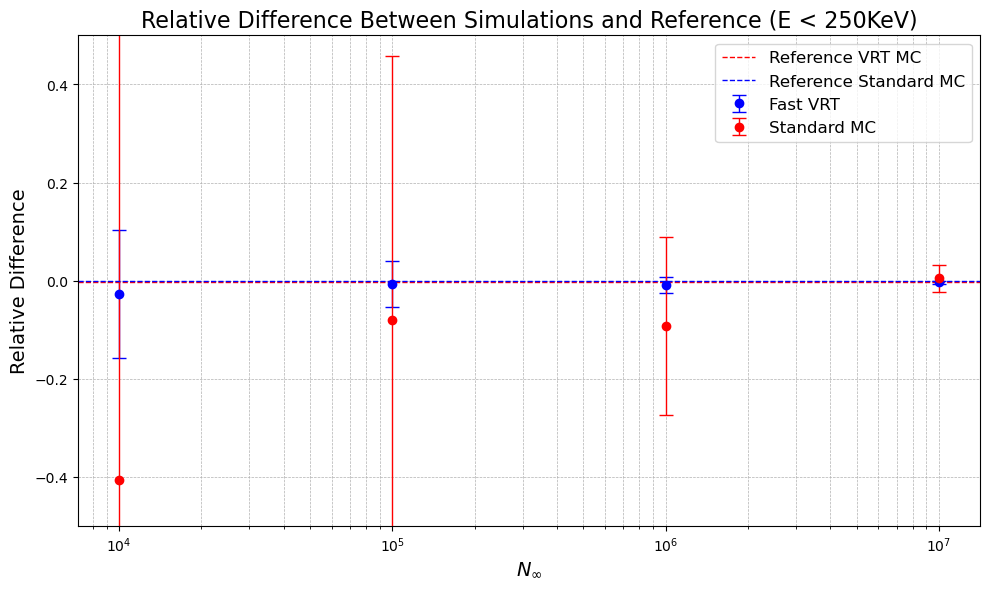

In [ ]:
N_ref = 3.37e-5
NBG_over_Nref_fast = []
NBG_over_Nref_std = []
errors_fast = []
errors_std = []

for N in N_values[-4:]:  # Adjust number of points if needed
    if len(N_BG_fast_with_cut[N]) == 0 or len(N_BG_std_with_cut[N]) == 0:
        print(f"Skipping N={N} due to empty data.")
        continue
    print(N)
    # Normalize N_BG by N_inf
    mean_fast = np.mean(N_BG_fast_with_cut[N])
    mean_std = np.mean(N_BG_std_with_cut[N])
    normalized_fast = (mean_fast - N_ref * N) / (N_ref * N)
    normalized_std = (mean_std - N_ref * N) / (N_ref * N)
 
    # Calculate errors (standard deviation of the counts)
    error_fast = np.std(N_BG_fast_with_cut[N]) / (N_ref * N)
    error_std = np.std(N_BG_std_with_cut[N]) / (N_ref * N)

    NBG_over_Nref_fast.append(normalized_fast)
    NBG_over_Nref_std.append(normalized_std)
    errors_fast.append(error_fast)
    errors_std.append(error_std)

# Convert to numpy arrays
NBG_over_Nref_fast = np.array(NBG_over_Nref_fast)
NBG_over_Nref_std = np.array(NBG_over_Nref_std)
errors_fast = np.array(errors_fast)
errors_std = np.array(errors_std)

# Plot the data
plt.figure(figsize=(10, 6))
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_fast,
    yerr=errors_fast,
    fmt='bo',
    label="Fast VRT",
    capsize=5,
    capthick=1,
    elinewidth=1,
)
plt.errorbar(
    N_values[-4:],
    NBG_over_Nref_std,
    yerr=errors_std,
    fmt='ro',
    label="Standard MC",
    capsize=5,
    capthick=1,
    elinewidth=1,
)





# Customize plot
plt.xscale('log')
plt.axhline(y= NBG_over_Nref_fast[-1], color='red', linestyle='--', linewidth=1, label="Reference VRT MC")
plt.axhline(y= 0, color='blue', linestyle='--', linewidth=1, label="Reference Standard MC")
plt.xlabel(r'$N_{\infty}$', fontsize=14)
plt.ylabel(r'Relative Difference', fontsize=14)
plt.title('Relative Difference Between Simulations and Reference (E < 250KeV)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


0.3279810148201908
10000
0.33699999999999997
3.3485413006028053
100000
3.37
33.42876500989878
1000000
33.699999999999996
335.8274799546642
10000000
337.0


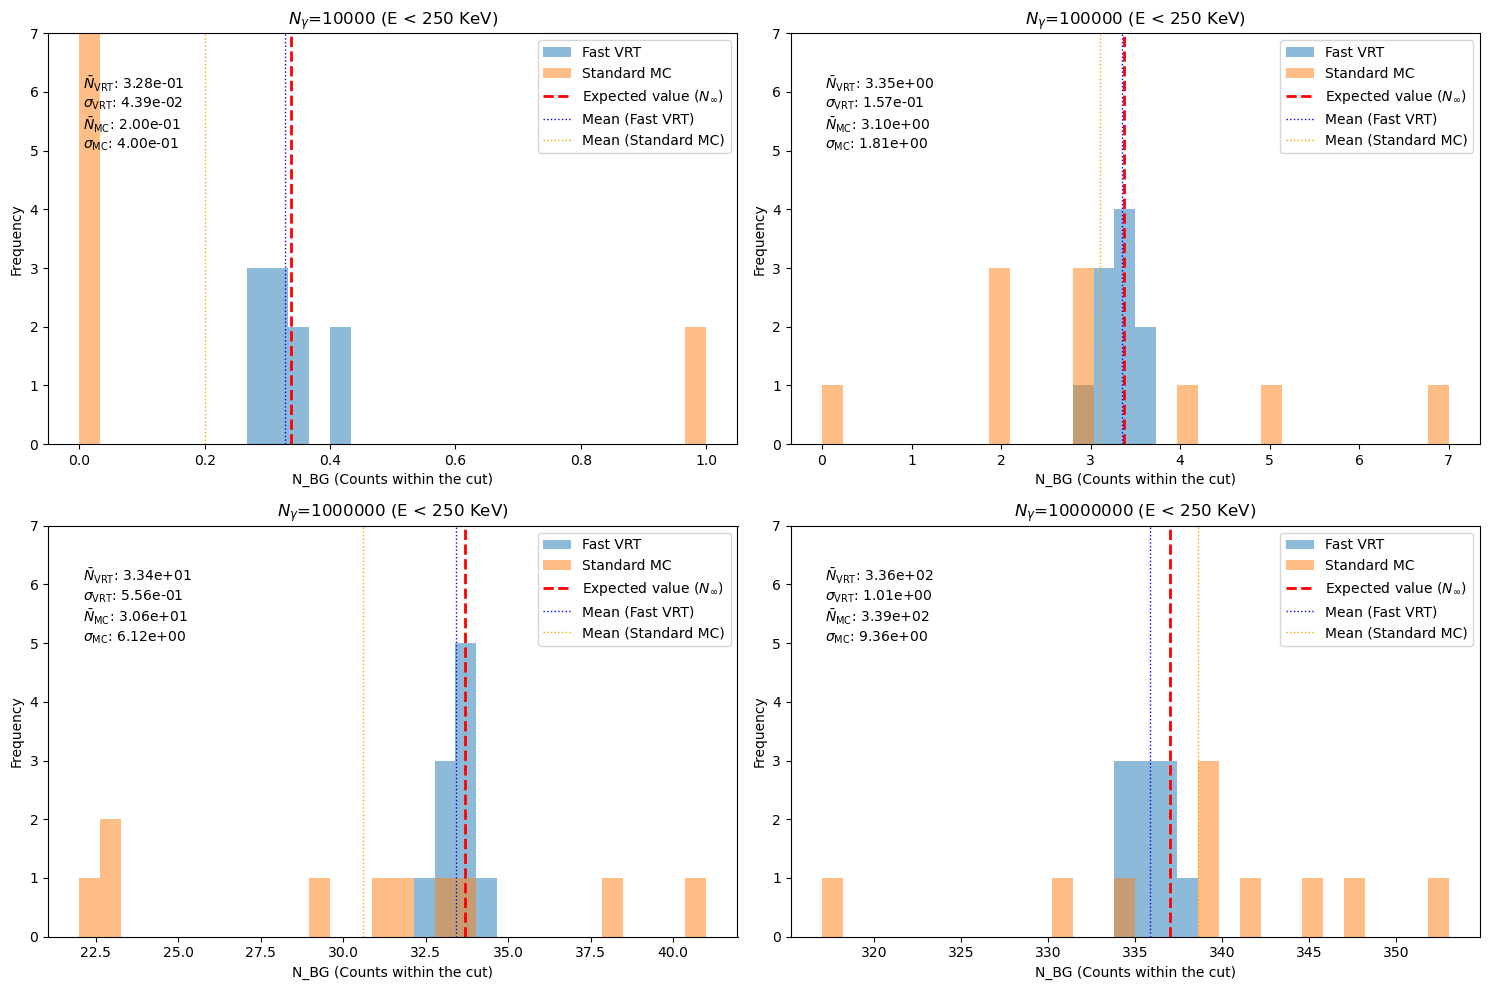

In [56]:
N_ref = 3.37e-5
# Filter N_values based on the threshold

# Ensure no more than 4 plots (for a 2x2 grid)
filtered_N_values =  [10000, 100000, 1000000, 10000000]

# Create a 2x2 grid for the subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make it easier to iterate

for idx, N in enumerate(filtered_N_values):
    ax = axes[idx]

    # Compute statistics
    Nbar_VRT = np.mean(N_BG_fast_with_cut[N])
    print(Nbar_VRT)
    Nbar_MC = np.mean(N_BG_std_with_cut[N])
    sigma_VRT = np.std(N_BG_fast_with_cut[N])
    sigma_MC = np.std(N_BG_std_with_cut[N])
    range_ = (np.min(N_BG_fast_with_cut[N] + N_BG_std_with_cut[N]), np.max(N_BG_fast_with_cut[N] + N_BG_std_with_cut[N]))

    # Plot histograms
    ax.hist(N_BG_fast_with_cut[N], bins=30, range=range_, alpha=0.5, label="Fast VRT")
    ax.hist(N_BG_std_with_cut[N], bins=30, range=range_, alpha=0.5, label="Standard MC")

    # Add vertical lines
    vline_value = N_ref * N
    print(N)
    print(vline_value)
    ax.axvline(x=vline_value, color='r', linestyle='dashed', linewidth=2, label="Expected value ($N_{\infty}$)")
    ax.axvline(x=Nbar_VRT, color='blue', linestyle='dotted', linewidth=1, label="Mean (Fast VRT)")
    ax.axvline(x=Nbar_MC, color='orange', linestyle='dotted', linewidth=1, label="Mean (Standard MC)")

    

    # Add labels and title
    ax.set_xlabel("N_BG (Counts within the cut)")
    ax.set_ylabel("Frequency")
    ax.set_title(f"$N_\gamma$={N} (E < 250 KeV)")
    #set the y range
    ax.set_ylim(0, 7)
    # Add text annotations
    ax.text(0.05, 0.9,
            f"$\\bar{{N}}_{{\\mathrm{{VRT}}}}$: {Nbar_VRT:.2e}\n"
            f"$\\sigma_{{\\mathrm{{VRT}}}}$: {sigma_VRT:.2e}\n"
            f"$\\bar{{N}}_{{\\mathrm{{MC}}}}$: {Nbar_MC:.2e}\n"
            f"$\\sigma_{{\\mathrm{{MC}}}}$: {sigma_MC:.2e}",
            transform=ax.transAxes, fontsize=10, color="black", verticalalignment='top')

    ax.legend(loc='upper right' )

# Remove any unused axes in the grid
for i in range(len(filtered_N_values), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Figure 5
In the last figure the relative uncertainty as a function of $N_\gamma$ of both the fast and standard montecarlo is plotted and fitted and the acceleration factor $(\frac{C^{MC}}{C^{VRT}})^2$ is calculated.

### Observations
- A acceleration factor of ~ 600 is calulated, which is lower than the ~ 1800 found in the Paper.

/tmp/ipykernel_505656/1449127541.py:30: RuntimeWarning: invalid value encountered in divide
  rel_uncertainty_MC = np.where(Nbar_MC_list > 0, sigma_MC_list / Nbar_MC_list, np.inf)


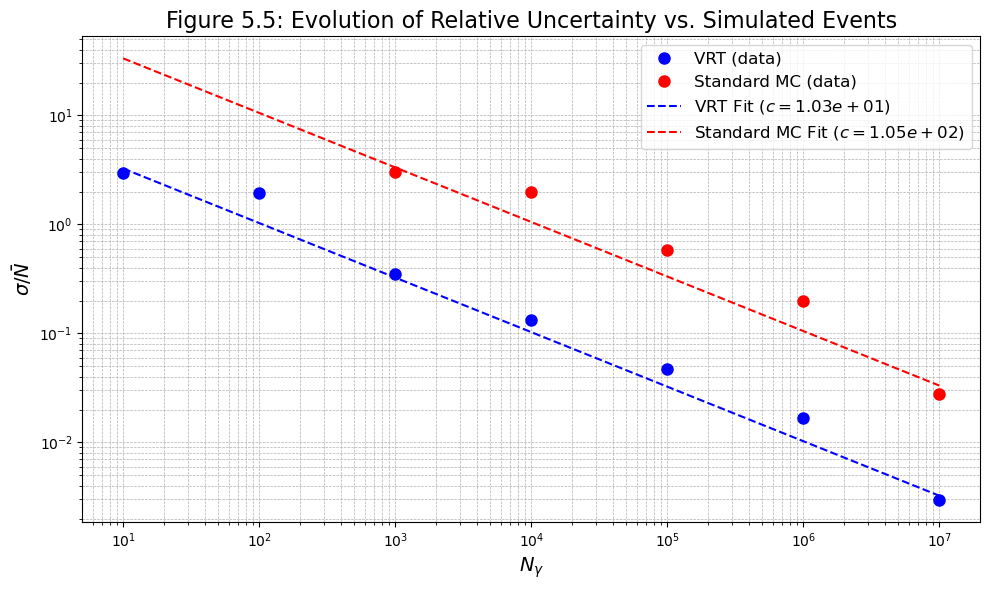

VRT Fit Parameter c: 1.03e+01
Standard MC Fit Parameter c: 1.05e+02
Acceleration Factor: 104.78


In [60]:
# Example usage:
from scipy.optimize import curve_fit
Nbar_VRT_list, Nbar_MC_list = [], []
sigma_VRT_list, sigma_MC_list = [], []

# Iterate over N_values and collect statistics
for N in N_values:
    if len(N_BG_fast_with_cut[N]) == 0 or len(N_BG_std_with_cut[N]) == 0:
        print(f"Skipping N={N} due to empty data.")
        continue
    
    Nbar_VRT = np.mean(N_BG_fast_with_cut[N])
    Nbar_MC = np.mean(N_BG_std_with_cut[N])
    sigma_VRT = np.std(N_BG_fast_with_cut[N])
    sigma_MC = np.std(N_BG_std_with_cut[N])

    Nbar_VRT_list.append(Nbar_VRT)
    Nbar_MC_list.append(Nbar_MC)
    sigma_VRT_list.append(sigma_VRT)
    sigma_MC_list.append(sigma_MC)

# Convert to numpy arrays
Nbar_VRT_list = np.array(Nbar_VRT_list)
Nbar_MC_list = np.array(Nbar_MC_list)
sigma_VRT_list = np.array(sigma_VRT_list)
sigma_MC_list = np.array(sigma_MC_list)

# Calculate relative uncertainties
rel_uncertainty_VRT = np.where(Nbar_VRT_list > 0, sigma_VRT_list / Nbar_VRT_list, np.inf)
rel_uncertainty_MC = np.where(Nbar_MC_list > 0, sigma_MC_list / Nbar_MC_list, np.inf)

# Filter valid data points
valid_indices_VRT = rel_uncertainty_VRT != np.inf
valid_indices_MC = rel_uncertainty_MC != np.inf

results =  {
    "valid_N_gamma_VRT": np.array(N_values)[valid_indices_VRT],
    "valid_N_gamma_MC": np.array(N_values)[valid_indices_MC],
    "valid_rel_uncertainty_VRT": rel_uncertainty_VRT[valid_indices_VRT],
    "valid_rel_uncertainty_MC": rel_uncertainty_MC[valid_indices_MC]
}

valid_N_gamma_VRT = results["valid_N_gamma_VRT"]
valid_N_gamma_MC = results["valid_N_gamma_MC"]
valid_rel_uncertainty_VRT = results["valid_rel_uncertainty_VRT"]
valid_rel_uncertainty_MC = results["valid_rel_uncertainty_MC"]

# Fit the data
popt_vrt, _ = curve_fit(uncertainty_model, valid_N_gamma_VRT, valid_rel_uncertainty_VRT)
popt_mc, _ = curve_fit(uncertainty_model, valid_N_gamma_MC, valid_rel_uncertainty_MC)

# Generate fitted curves
N_gamma_fit = np.logspace(np.log10(min(N_values)), np.log10(max(N_values)), 100)
fit_vrt = uncertainty_model(N_gamma_fit, *popt_vrt)
fit_mc = uncertainty_model(N_gamma_fit, *popt_mc)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.loglog(valid_N_gamma_VRT, valid_rel_uncertainty_VRT, 'bo', label='VRT (data)', markersize=8)
plt.loglog(valid_N_gamma_MC, valid_rel_uncertainty_MC, 'ro', label='Standard MC (data)', markersize=8)
plt.loglog(N_gamma_fit, fit_vrt, 'b--', label=f'VRT Fit ($c={popt_vrt[0]:.2e}$)')
plt.loglog(N_gamma_fit, fit_mc, 'r--', label=f'Standard MC Fit ($c={popt_mc[0]:.2e}$)')

# Customize plot
plt.xlabel(r'$N_\gamma$', fontsize=14)
plt.ylabel(r'$\sigma / \bar{N}$', fontsize=14)
plt.title('Figure 5.5: Evolution of Relative Uncertainty vs. Simulated Events', fontsize=16)
plt.legend(fontsize=12)
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Print fit parameters
print(f"VRT Fit Parameter c: {popt_vrt[0]:.2e}")
print(f"Standard MC Fit Parameter c: {popt_mc[0]:.2e}")
print(f"Acceleration Factor: {(popt_mc[0] / popt_vrt[0])**2:.2f}")

### Figure 6 (Not in the paper)
In this extra graph I changes the logic of the standard simulation to investigate if the descrepancy of the convergence value of the fast and standard simulations are caused by improper clustering and bremstrahlung. I killed brem photons when they are created and add their energy back to the electron causing it to be clustered in a single energy deposit instead of being carried away and deposited elsewhere.

### Simulations used for Figure 6 (1.5 MeV source)
- "run_119": Standard Simulation with Large clustering and brehmstralung photons killed on creation and energt added back to the electron.
- "run_120": Standard Simulation with normal clustering and brehmstralung photons killed on creation and energt added back to the electron.
- "run_106": Standard simulation.

### Cuts used
- "cut_main_ndet1": Selects events with a single scatter of the main photon (either PE or Compton), a single energy deposit and the photon has not scattered before entering the xenon.
- "cut_main_escaped": Selects events with a single scatter of the main photon (either PE or Compton), the main photon escaped without scattering again and has not scattered before entering the xenon.
- "cut_hit_main2" : Selects all hits within the FV and hits below $E_{max} = 250 KeV$ 

## Observations
- The main thing to note here is the difference between the "ndet=1" cut and the "escaped" cut. 
- The "ndet=1" selects events with a single energy deposit, so if a brem photon carried away some energy and deposits it somewhere else these would not be included in the cut.
- the "escaped" cut selects events where the main photon scattered only once and then escapes the xenon without scattering again. This cut will include events with additional brem deposits caused by a brem photon.
- The simulations with killed bremstrahlung photons that are added back to the electron will only have a single deposit and thus be included in the escaped cut, while in the normal simulation (with brem propagation) they will not be included.
- In the graph this can be seen by the "Dir + brem + escaped" events that are present in the "escaped" cut on the standard simulation but are not there in the same cut on the simulations without brem propagation. This is because when the brem photon energy is added back to the electron, the single energy deposit will be over the 250 KeV cut. 


In [4]:
# test run with normal clustering & brem locally

# test run with normal clustering and normal brem
#control_run = Geant4Analyzer("run_106", first_only=True)


cut_main_ndet1 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] == 1) &
                            # direct and escaped gamma
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

cut_main_escaped = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            
                            # direct and escaped gamma
                            (ak.values_astype(data['type'], int) & 3 == 1) &
                            #  check escaped 
                            (ak.values_astype(data['type'], int) & 16 == 16)
                        )

cut_hit_main2 = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 250)

In [5]:

no_brem_with_FV = Geant4Analyzer("run_145", first_only=False)
no_brem_small_FV = copy.deepcopy(no_brem_with_FV)
no_brem_without_FV = copy.deepcopy(no_brem_with_FV)

with_brem_with_FV = Geant4Analyzer("run_139", first_only=False)
with_brem_small_FV = copy.deepcopy(with_brem_with_FV)
with_brem_without_FV = copy.deepcopy(with_brem_with_FV)

Fast_with_FV = Geant4Analyzer("run_140", first_only=False)
Fast_with_FV_small = copy.deepcopy(Fast_with_FV)
fast_without_FV = Geant4Analyzer("run_141", first_only=False)
clear_output()

In [11]:

cut_main_ndet1 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] == 1) &
                           
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

cut_hit_with_FV = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 5001)
cut_hit_with_small_FV = lambda data: (data['r'] < 530 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 5001)
cut_hit_without_FV = lambda data: (data['r'] < 650 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 5001)

no_brem_with_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
no_brem_small_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_small_FV)
no_brem_without_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_without_FV)

with_brem_with_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
with_brem_small_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_small_FV)
with_brem_without_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_without_FV)

Fast_with_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
Fast_with_FV_small.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_small_FV)
fast_without_FV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_without_FV)


data_with = {'No Brem with FV': no_brem_with_FV, 'Brem with FV': with_brem_with_FV, 'Fast with FV': Fast_with_FV}
data_without = {'No Brem without FV': no_brem_without_FV, 'Brem without FV': with_brem_without_FV, 'Fast without FV': fast_without_FV}
data_small = {'No Brem with small FV': no_brem_small_FV, 'Brem with small FV': with_brem_small_FV, 'Fast with small FV': Fast_with_FV_small}

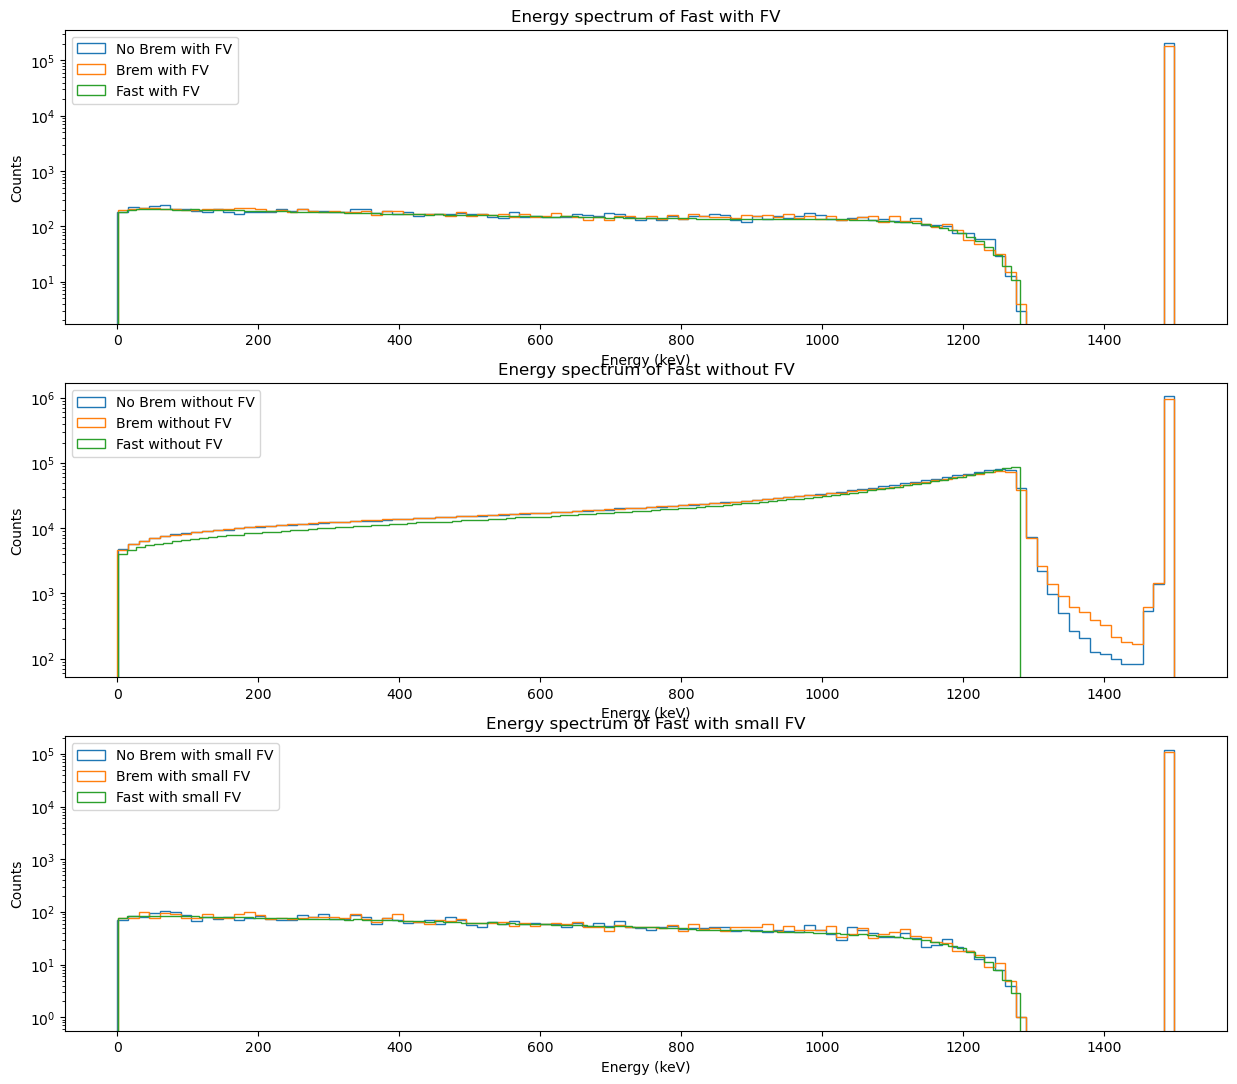

: 

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(15, 13))
axs = ax.flatten()
# plot every data dict in seperate plot
i=0
print(data_small)
for data_dict in [data_without,data_with, data_small]:
    
    for key, data in data_dict.items():
        data.plot_histogram('eh', ax=axs[i], bins=100, label=key, show=False)
        axs[i].set_title(f'Energy spectrum of {key}')
        axs[i].set_yscale('log')
        axs[i].legend(loc = 'upper left')
    i+=1

clear_output()
plt.show()

In [31]:

std_1500KeV = Geant4Analyzer("run_149", first_only=False)
fast_1500KeV = Geant4Analyzer("run_156", first_only=False)

std_1500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)



Initialized Geant4Analyzer with run_id=run_149, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250110_100636/std_0.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_3.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_2.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_4.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_1.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_9.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_6.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_5.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_8.root', '/data/xenon/edecleen/master/data_ez/20250110_100636/std_7.root']
Loading /data/xenon/edecleen/master/data_ez/20250110_100636/std_0.root
Loading /data/xenon/edecleen/master/data_ez/20250110_100636/std_3.root
Loading /data/xenon/edecleen/master/data_ez/20250110_100636/std_2.root
Loading /data/xenon/edecleen/master/data_ez/20250110_

integral Standard= 199719.0
integral Fast= 231820.2644464839


/tmp/ipykernel_2207927/3836930296.py:27: RuntimeWarning: divide by zero encountered in divide
  abs_rel_diff = (hist_std - hist_fast)/ hist_fast
/tmp/ipykernel_2207927/3836930296.py:27: RuntimeWarning: invalid value encountered in divide
  abs_rel_diff = (hist_std - hist_fast)/ hist_fast


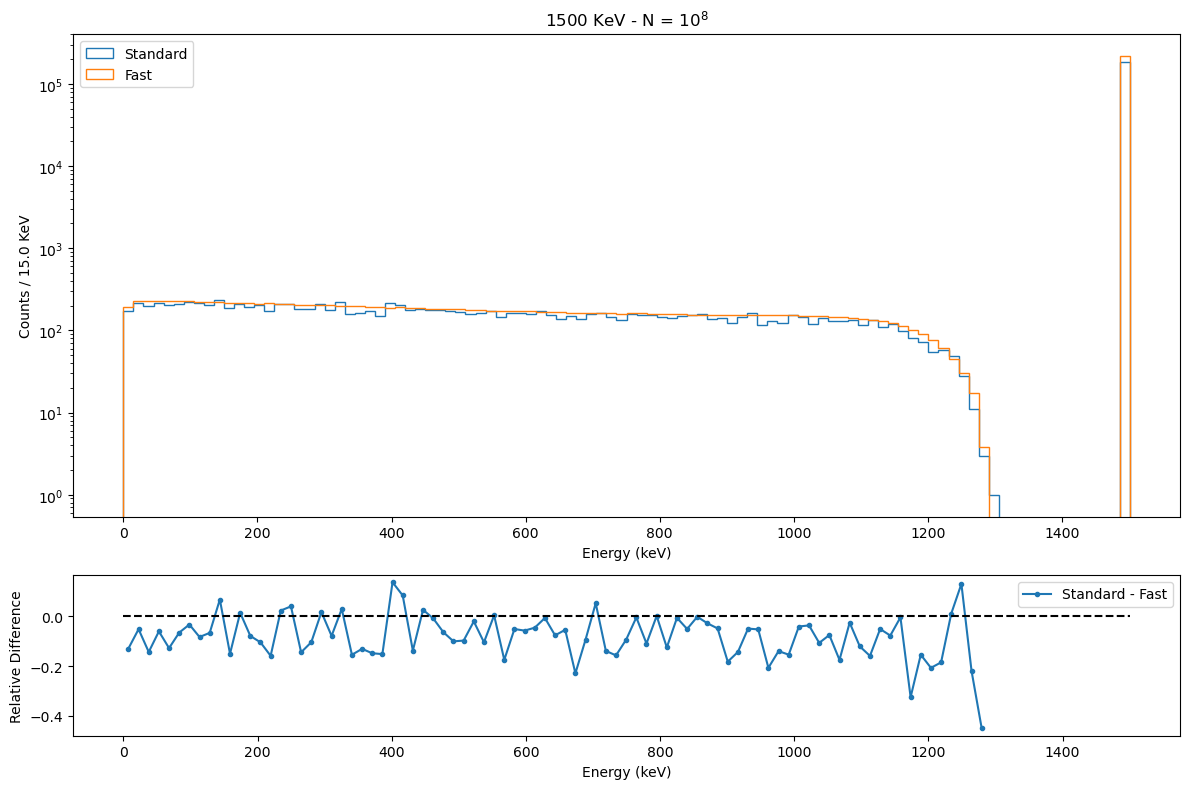

In [ ]:
# Data for plotting
std_data = std_1500KeV
fast_data = fast_1500KeV

# Create a 2-row layout: one for the energy histogram and one for the difference plot
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 1]})

# Logarithmic energy plot
ax_energy = axs[0]
std_1500KeV.plot_histogram('eh', ax=ax_energy, bins=100, label="Standard", show=False, range=(0, 1500 + 1))
fast_1500KeV.plot_histogram('eh', ax=ax_energy, bins=100, label="Fast", show=False, range=(0, 1500 + 1))
ax_energy.set_yscale('log')
ax_energy.set_title(f"1500 KeV & N = $10^8$")
ax_energy.set_xlabel("Energy (keV)")
ax_energy.set_ylabel("Counts / 15.0 KeV")
ax_energy.legend()

# Difference plot
ax_diff = axs[1]
bins = np.linspace(0, 1500 - 1, 100)

# Compute histograms
hist_std, _ = np.histogram(std_1500KeV.data['eh'], bins=bins)
hist_fast, _ = np.histogram(fast_1500KeV.data['eh'], bins=bins, weights=np.exp(fast_1500KeV.data['wh']))

# Calculate deviation
abs_rel_diff = (hist_std - hist_fast)/ hist_fast

# Bin centers for plotting
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Plot difference
ax_diff.plot(bin_centers, abs_rel_diff, label="Standard - Fast", marker='o', markersize=3, color='tab:blue')
ax_diff.hlines(0, xmin=0, xmax=1500, linestyle='--', color='black')
ax_diff.set_xlabel("Energy (keV)")
ax_diff.set_ylabel("Relative Difference")
ax_diff.legend()

# Adjust layout
plt.tight_layout()
plt.show()

In [6]:

std_500KeV = Geant4Analyzer("run_147", first_only=True)
std_500KeV_no_paircr = Geant4Analyzer("run_170", first_only=True)
fast_500KeV = Geant4Analyzer("run_151", first_only=True)

std_1000KeV = Geant4Analyzer("run_148", first_only=True)
std_1000KeV_no_paircr = Geant4Analyzer("run_169", first_only=True)
std_1000KeV_no_paircr_nobrem = Geant4Analyzer("run_178", first_only=False)
std_1000KeV_nobrem = Geant4Analyzer("run_185", first_only=False)
fast_1000KeV = Geant4Analyzer("run_155", first_only=True)
fast_1000KeV_with_pairprod = Geant4Analyzer("run_186", first_only=False)


std_1500KeV = Geant4Analyzer("run_149", first_only=True)
std_1500KeV_no_paircr = Geant4Analyzer("run_168", first_only=True)
std_1500KeV_no_paircr_nobrem = Geant4Analyzer("run_177", first_only=False)
fast_1500KeV = Geant4Analyzer("run_156", first_only=True)


# # run run_166 (w/o pair creation) or run_150 for std_2500KeV and run_165 no brem
std_2500KeV = Geant4Analyzer("run_150", first_only=True)
std_2500KeV_no_paircr = Geant4Analyzer("run_166", first_only=True)
std_2500KeV_no_paircr_nobrem = Geant4Analyzer("run_176", first_only=False)
fast_2500KeV = Geant4Analyzer("run_167", first_only=True)

# run_174 for 5MeV no pair prod (10m in 10 jobs), 172 for normal(j=10 n =100m) and 173 fast (j=10 n =100m)
std_5000KeV = Geant4Analyzer("run_172", first_only=True)
std_5000KeV_no_paircr = Geant4Analyzer("run_174", first_only=False)
std_5000KeV_no_paircr_nobrem = Geant4Analyzer("run_175", first_only=False)
fast_5000KeV = Geant4Analyzer("run_173", first_only=True)

fast_5000KeV_with_pairprod = Geant4Analyzer("run_182", first_only=False)

std_5000KeV_no_brem = Geant4Analyzer("run_184", first_only=False)
clear_output()

In [4]:
cut_main_ndet1 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] == 1) &
                           
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

cut_hit_with_FV = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 5001)



std_500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_500KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

std_1000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_no_paircr_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1000KeV_with_pairprod.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)



std_1500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1500KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1500KeV_no_paircr_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

std_2500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_2500KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_2500KeV_no_paircr_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_2500KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

std_5000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_paircr_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_5000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

fast_5000KeV_with_pairprod.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_brem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

clear_output()

integral Standard= 24186.0
integral Fast= 25205.774261496786
integral Standard (no pair)= 24080.0
integral Standard (no pair, no brem)= 25054.0
integral Standard= 20253.0
integral Fast= 23285.61833925889
integral Standard (no pair)= 21067.0
integral Standard (no pair, no brem)= 23211.0
integral Standard= 12952.0
integral Fast= 23304.50972025755
integral Standard (no pair)= 18559.0
integral Standard (no pair, no brem)= 23118.0
integral Standard= 4845.0
integral Fast= 32439.29547646716
integral Standard (no pair)= 20172.0
integral Standard (no pair, no brem)= 32081.0


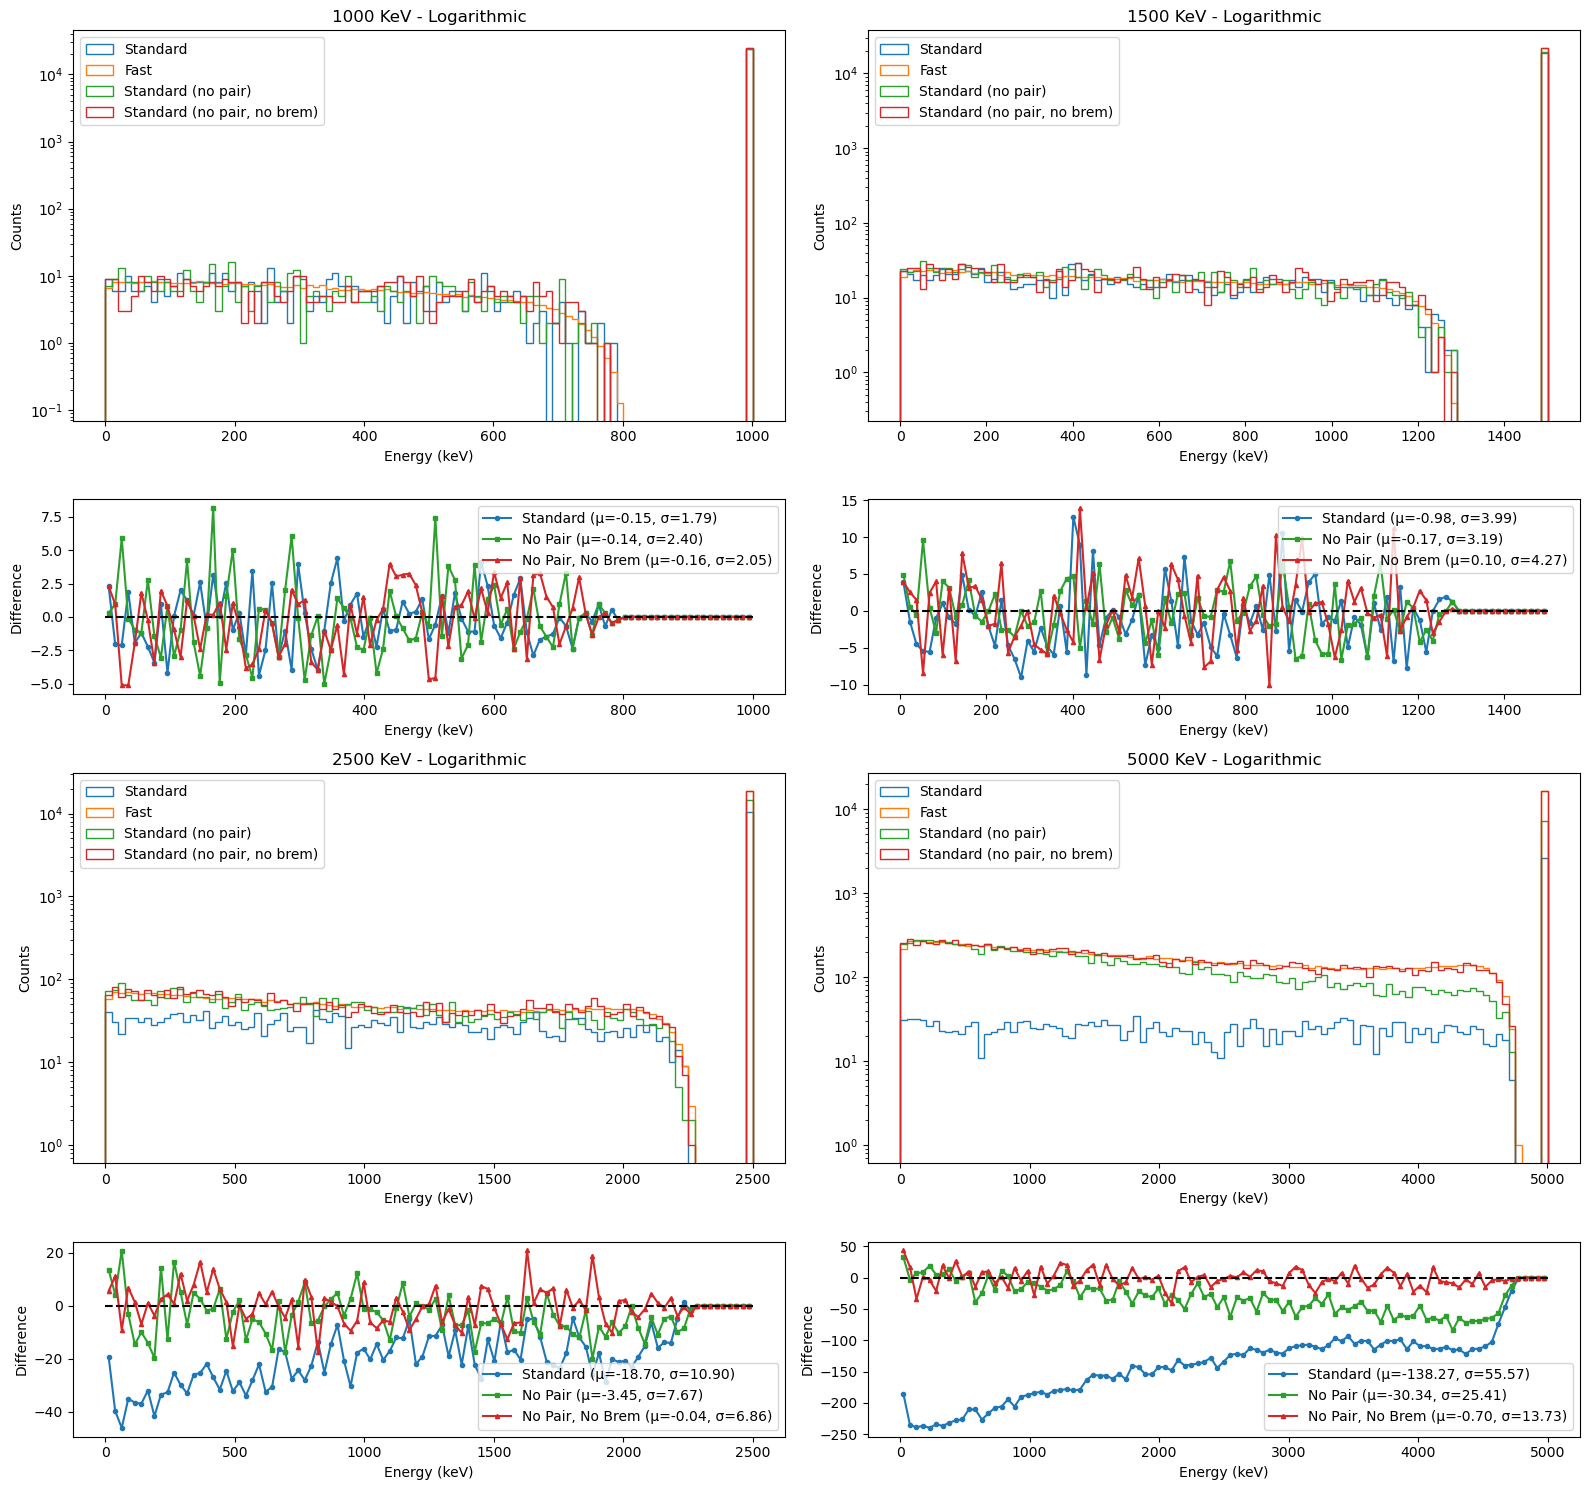

In [ ]:
# Number of energy levels
energy_vals = [1000, 1500, 2500, 5000]
data = [
    [std_1000KeV, fast_1000KeV, std_1000KeV_no_paircr, std_1000KeV_no_paircr_nobrem],
    [std_1500KeV, fast_1500KeV, std_1500KeV_no_paircr, std_1500KeV_no_paircr_nobrem],
    [std_2500KeV, fast_2500KeV, std_2500KeV_no_paircr, std_2500KeV_no_paircr_nobrem],
    [std_5000KeV, fast_5000KeV, std_5000KeV_no_paircr, std_5000KeV_no_paircr_nobrem]
]

# Create a 4x2 grid layout
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 15), gridspec_kw={"height_ratios": [2, 1] * 2})
axs = axs.reshape(4, 2)  # 4 rows and 2 subplots in each row

# Loop through the energies and data
for i, (energy, data_) in enumerate(zip(energy_vals, data)):
    row = i // 2
    col = i % 2

    # Logarithmic energy plot
    ax_energy = axs[2 * row, col]
    data_[0].plot_histogram('eh', ax=ax_energy, bins=100, label="Standard", show=False, range=(0, energy + 1))
    data_[1].plot_histogram('eh', ax=ax_energy, bins=100, label="Fast", show=False, range=(0, energy + 1))
    data_[2].plot_histogram('eh', ax=ax_energy, bins=100, label="Standard (no pair)", show=False, range=(0, energy + 1))
    data_[3].plot_histogram('eh', ax=ax_energy, bins=100, label="Standard (no pair, no brem)", show=False, range=(0, energy + 1))
    ax_energy.set_yscale('log')
    ax_energy.set_ylabel(f"Counts / {round(energy / 100)}.0 KeV")
    ax_energy.set_title(f"{energy} KeV & N = $10^7$")
    ax_energy.legend()

    # Difference plot
    ax_diff = axs[2 * row + 1, col]
    bins = np.linspace(0, energy - 1, 100)

    # Compute histograms
    hist_std, _ = np.histogram(data_[0].data['eh'], bins=bins)
    hist_fast, _ = np.histogram(data_[1].data['eh'], bins=bins, weights=np.exp(data_[1].data['wh']))
    hist_no_pair, _ = np.histogram(data_[2].data['eh'], bins=bins)
    hist_no_pair_nobrem, _ = np.histogram(data_[3].data['eh'], bins=bins)

    # Calculate deviations
    abs_diff_fast_std = hist_std - hist_fast
    abs_diff_no_pair_std = hist_no_pair - hist_fast
    abs_diff_no_pair_nobrem_std = hist_no_pair_nobrem - hist_fast

    # Calculate mean and std of deviations
    mean_diff_std = np.mean(abs_diff_fast_std)
    std_diff_std = np.std(abs_diff_fast_std)

    mean_diff_no_pair = np.mean(abs_diff_no_pair_std)
    std_diff_no_pair = np.std(abs_diff_no_pair_std)

    mean_diff_no_pair_nobrem = np.mean(abs_diff_no_pair_nobrem_std)
    std_diff_no_pair_nobrem = np.std(abs_diff_no_pair_nobrem_std)

    # Bin centers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Plot differences
    ax_diff.plot(bin_centers, abs_diff_fast_std, label=f"Standard (μ={mean_diff_std:.2f}, σ={std_diff_std:.2f})", marker='o', markersize=3, color='tab:blue')
    ax_diff.plot(bin_centers, abs_diff_no_pair_std, label=f"No Pair (μ={mean_diff_no_pair:.2f}, σ={std_diff_no_pair:.2f})", marker='s', markersize=3, color='tab:green')
    ax_diff.plot(bin_centers, abs_diff_no_pair_nobrem_std, label=f"No Pair, No Brem (μ={mean_diff_no_pair_nobrem:.2f}, σ={std_diff_no_pair_nobrem:.2f})", marker='^', markersize=3, color='tab:red')

    ax_diff.hlines(0, xmin=0, xmax=energy, linestyle='--', color='black')
    ax_diff.set_xlabel("Energy (keV)")
    ax_diff.set_ylabel("Difference")
    ax_diff.legend()

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
# 1k 5k
# FAST WITH PAIPROD (CHECK)  run_187 run_188

# STANDAARD (CHECK)  run_195 run_196 (196 is standard and 197 IS NOT)
 
# FAST (CHECK)  run_193 run_194
# STANDAARD NO PAIR, NO BREM (Check)  run_191 run_192

# STANDAARD NO BREM (CHECK) run_189 run_190

std_1000KeV_no_paircr_nobrem_100m = Geant4Analyzer("run_201", first_only=False, start_index=0, file_count=4)
fast_1000KeV_with_pairprod_100m = Geant4Analyzer("run_205", first_only=False, start_index=0, file_count=4)
fast_1000KeV_100m = Geant4Analyzer("run_203", first_only=False, start_index=0, file_count=4)
std_1000KeV_100m = Geant4Analyzer("run_207", first_only=False, start_index=0, file_count=4)



std_5000KeV_no_paircr_nobrem_100m = Geant4Analyzer("run_202", first_only=False, start_index=0, file_count=4)
fast_5000KeV_with_pairprod_100m = Geant4Analyzer("run_206", first_only=False, start_index=0, file_count=4)
fast_5000KeV_100m = Geant4Analyzer("run_173", first_only=False, start_index=0, file_count=4)
std_5000KeV_100m = Geant4Analyzer("run_208", first_only=False, start_index=0, file_count=4)

std_5000KeV_no_brem_100m = Geant4Analyzer("run_225", first_only=False, start_index=0, file_count=4)
std_1000KeV_no_brem_100m = Geant4Analyzer("run_224", first_only=False, start_index=0, file_count=4)
clear_output()


In [5]:
cut_main_ndet1 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] == 1) &
                           
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

cut_hit_with_FV = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 5001)


std_1000KeV_no_brem_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_no_paircr_nobrem_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1000KeV_with_pairprod_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1000KeV_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

std_5000KeV_no_brem_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_paircr_nobrem_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_5000KeV_with_pairprod_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_5000KeV_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_100m.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

integral Standard= 96109.0
integral Fast= 100789.88292473038
integral Fast with pair= 101530.25418508833
integral Standard (no pair, no brem)= 100956.0
integral Standard (no brem)= 100233.0


integral Standard= 19254.0
integral Fast= 129652.76945408872
integral Fast with pair= 35295.52794783124
integral Standard (no pair, no brem)= 128039.0
integral Standard (no brem)= 34557.0


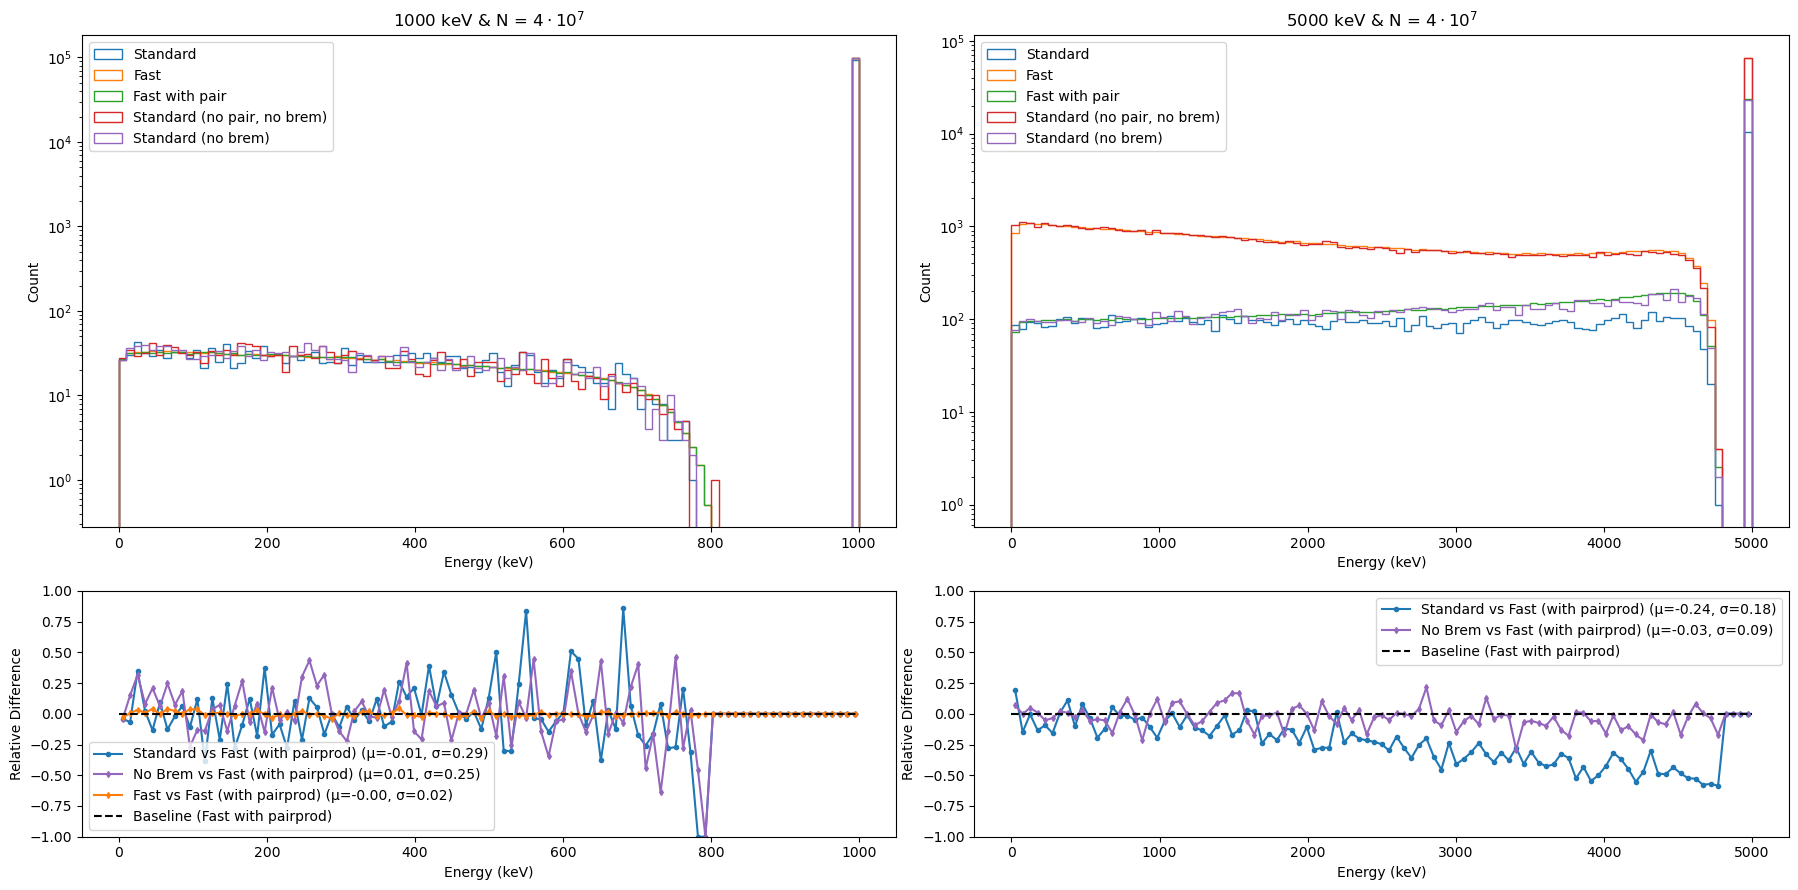

In [15]:
data_sets = {
    1000: [std_1000KeV_100m, fast_1000KeV_100m, fast_1000KeV_with_pairprod_100m, std_1000KeV_no_paircr_nobrem_100m, std_1000KeV_no_brem_100m],
    5000: [std_5000KeV_100m, fast_5000KeV_100m, fast_5000KeV_with_pairprod_100m, std_5000KeV_no_paircr_nobrem_100m, std_5000KeV_no_brem_100m]
}

fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(18, 9),
    gridspec_kw={"height_ratios": [2, 1]}  # Larger height for energy plots
)

axs = axs.reshape(2, 2)  # Reshape to ensure 2 rows, 2 columns

for i, (energy, data_set) in enumerate(data_sets.items()):
    col = i  # Energy and difference plots in the same column

    # Energy plot (top row)
    ax_energy = axs[0, col]
    for data, label in zip(data_set, ["Standard", "Fast", "Fast with pair", "Standard (no pair, no brem)", "Standard (no brem)"]):
        data.plot_histogram('eh', ax=ax_energy, bins=100, label=label, show=False, range=(0, energy + 1))

    ax_energy.set_yscale('log')
    ax_energy.set_title(f"{energy} keV & N = $4 \cdot 10^7$")
    ax_energy.legend()
    ax_energy.set_xlabel("Energy (keV)")
    ax_energy.set_ylabel("Count")

    # Difference plot (bottom row)
    ax_diff = axs[1, col]
    bins = np.linspace(0, energy - 1, 100)

    # Compute histograms for differences
    hist_std, _ = np.histogram(data_set[0].data['eh'], bins=bins)
    hist_fast, _ = np.histogram(data_set[1].data['eh'], bins=bins, weights=np.exp(data_set[1].data['wh']))
    hist_fast_with_pairprod, _ = np.histogram(data_set[2].data['eh'], bins=bins, weights=np.exp(data_set[2].data['wh']))
    hist_no_pair_nobrem, _ = np.histogram(data_set[3].data['eh'], bins=bins)
    hist_no_brem, _ = np.histogram(data_set[4].data['eh'], bins=bins)

    # Compute relative differences with safe normalization
    nonzero_mask = hist_fast_with_pairprod > 0  # Avoid division by zero
    relative_diff_fast_std = np.zeros_like(hist_fast_with_pairprod, dtype=np.float64)
    
    relative_diff_no_pair_nobrem_std = np.zeros_like(hist_fast_with_pairprod, dtype=np.float64)
    relative_diff_no_brem_std = np.zeros_like(hist_fast_with_pairprod, dtype=np.float64)
    relative_diff_fast = np.zeros_like(hist_fast_with_pairprod, dtype=np.float64)
    
    # Perform safe normalization
    relative_diff_fast_std[nonzero_mask] = (hist_std[nonzero_mask] - hist_fast_with_pairprod[nonzero_mask]) / hist_fast_with_pairprod[nonzero_mask]
    relative_diff_no_pair_nobrem_std[nonzero_mask] = (hist_no_pair_nobrem[nonzero_mask] - hist_fast_with_pairprod[nonzero_mask]) / hist_fast_with_pairprod[nonzero_mask]
    relative_diff_no_brem_std[nonzero_mask] = (hist_no_brem[nonzero_mask] - hist_fast_with_pairprod[nonzero_mask]) / hist_fast_with_pairprod[nonzero_mask]
    relative_diff_fast[nonzero_mask] = (hist_fast[nonzero_mask] - hist_fast_with_pairprod[nonzero_mask]) / hist_fast_with_pairprod[nonzero_mask]

    # Compute mean and standard deviation for relative differences
    mean_fast_std = np.mean(relative_diff_fast_std[nonzero_mask])
    std_fast_std = np.std(relative_diff_fast_std[nonzero_mask])


    mean_no_pair_nobrem_std = np.mean(relative_diff_no_pair_nobrem_std[nonzero_mask])
    std_no_pair_nobrem_std = np.std(relative_diff_no_pair_nobrem_std[nonzero_mask])

    mean_no_brem_std = np.mean(relative_diff_no_brem_std[nonzero_mask])
    std_no_brem_std = np.std(relative_diff_no_brem_std[nonzero_mask])

    mean_fast = np.mean(relative_diff_fast[nonzero_mask])
    std_fast = np.std(relative_diff_fast[nonzero_mask])

    # Bin centers for plotting
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Plot the relative differences
    ax_diff.plot(bin_centers, relative_diff_fast_std, label=f"Standard vs Fast (with pairprod) (μ={mean_fast_std:.2f}, σ={std_fast_std:.2f})", marker='o', markersize=3, color='tab:blue')
    
    
    ax_diff.plot(bin_centers, relative_diff_no_brem_std, label=f"No Brem vs Fast (with pairprod) (μ={mean_no_brem_std:.2f}, σ={std_no_brem_std:.2f})", marker='d', markersize=3, color='tab:purple')
    if i == 0:
        # ax_diff.plot(bin_centers, relative_diff_no_pair_nobrem_std, label=f"No Pair, No Brem vs Fast (with pairprod) (μ={mean_no_pair_nobrem_std:.2f}, σ={std_no_pair_nobrem_std:.2f})", marker='^', markersize=3, color='tab:red')
        ax_diff.plot(bin_centers, relative_diff_fast, label=f"Fast vs Fast (with pairprod) (μ={mean_fast:.2f}, σ={std_fast:.2f})", marker='d', markersize=3, color='tab:orange')
    ax_diff.set_ylim(-1,1)
    ax_diff.hlines(0, xmin=0, xmax=energy, linestyle='--', color='black', label="Baseline (Fast with pairprod)")
    ax_diff.set_xlabel("Energy (keV)")
    ax_diff.set_ylabel("Relative Difference")
    ax_diff.legend()

# Adjust layout
plt.tight_layout()
plt.savefig("energy_comparison_100m_5k.png")
plt.show()

In [62]:

cut_main_ndet2 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 2)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] == 2) &
                           
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

cut_hit_with_FV = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 2501)

In [58]:
double_fast_100k = Geant4Analyzer("run_161", first_only=False)

Initialized Geant4Analyzer with run_id=run_161, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250113_143128/fast_0.root']
Loading /data/xenon/edecleen/master/data_ez/20250113_143128/fast_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250113_143128/fast_0.root']


In [108]:

cut_main_ndet_over0 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] > 0) &
                           
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

double_fast_100k.preprocess_data(cut=cut_main_ndet_over0, cut_hit=cut_hit_with_FV)

std_2500KeV.preprocess_data(cut=cut_main_ndet2, cut_hit=cut_hit_with_FV)

integral Standard double scatter @ 2500 KeV= 373390.0
integral Fast double scatter @ 2500 KeV= 2067.984465294059


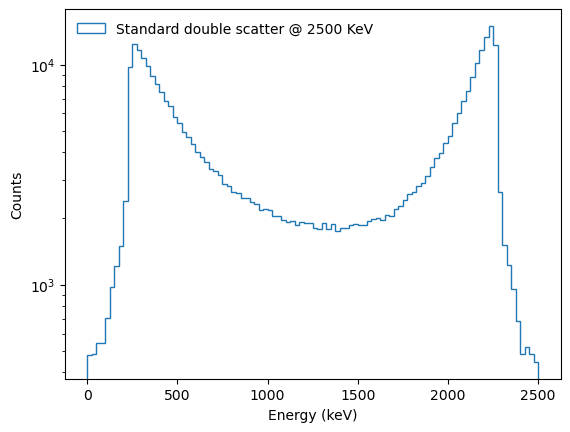

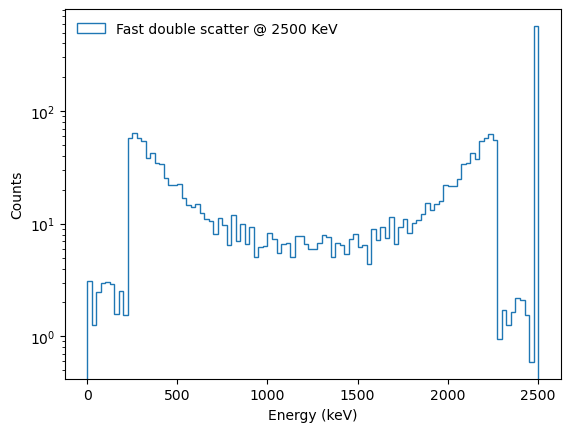

In [109]:
std_2500KeV.plot_histogram('eh', bins=100, label='Standard double scatter @ 2500 KeV')
plt.yscale('log')
double_fast_100k.plot_histogram('eh', bins=100, label='Fast double scatter @ 2500 KeV')
plt.yscale('log')
plt.show()

In [18]:
cut_main_ndet1 = lambda data: (   (data['ncomp'][:, 0] + data['ncomp'][:, 1] + data['nphot'][:,0] + data['nphot'][:,1] == 1)  &
                            (data['ndet'][:, 0]+ data['ndet'][:, 1] == 1) &
                           
                            (ak.values_astype(data['type'], int) & 3 == 1) 

                        )

cut_hit_with_FV = lambda data: (data['r'] < 570 ) & (data['zh'] > -670) & (data['zh'] < 670) & (data['eh'] < 5001)


std_1000KeV = Geant4Analyzer("run_148", first_only=True)
std_1000KeV_no_paircr = Geant4Analyzer("run_169", first_only=True)
std_1000KeV_no_paircr_nobrem = Geant4Analyzer("run_178", first_only=False)
std_1000KeV_nobrem = Geant4Analyzer("run_185", first_only=False)
fast_1000KeV = Geant4Analyzer("run_155", first_only=True)
fast_1000KeV_with_pairprod = Geant4Analyzer("run_186", first_only=False)

# run_174 for 5MeV no pair prod (10m in 10 jobs), 172 for normal(j=10 n =100m) and 173 fast (j=10 n =100m)
std_5000KeV = Geant4Analyzer("run_172", first_only=True)
std_5000KeV_no_paircr = Geant4Analyzer("run_174", first_only=False)
std_5000KeV_no_paircr_nobrem = Geant4Analyzer("run_175", first_only=False)
fast_5000KeV = Geant4Analyzer("run_173", first_only=True)

fast_5000KeV_with_pairprod = Geant4Analyzer("run_182", first_only=False)

std_5000KeV_no_brem = Geant4Analyzer("run_184", first_only=False)



Initialized Geant4Analyzer with run_id=run_148, label=
Loading data from /data/xenon/edecleen/master/data_ez/20250110_100630/std_0.root
Loading /data/xenon/edecleen/master/data_ez/20250110_100630/std_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250110_100630/std_0.root']
Initialized Geant4Analyzer with run_id=run_169, label=
Loading data from /data/xenon/edecleen/master/data_ez/20250115_132931/std_nopairprod_0.root
Loading /data/xenon/edecleen/master/data_ez/20250115_132931/std_nopairprod_0.root
Data loaded from 1 files
Data loaded from ['/data/xenon/edecleen/master/data_ez/20250115_132931/std_nopairprod_0.root']
Initialized Geant4Analyzer with run_id=run_178, label=
Loading data from ['/data/xenon/edecleen/master/data_ez/20250116_132727/std_nobrem_noprod_0.root', '/data/xenon/edecleen/master/data_ez/20250116_132727/std_nobrem_noprod_7.root', '/data/xenon/edecleen/master/data_ez/20250116_132727/std_nobrem_noprod_2.root', '/data/xenon/edecleen

In [19]:


std_1000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_no_paircr_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_1000KeV_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1000KeV_with_pairprod.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_1000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

std_5000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_paircr.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_paircr_nobrem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
fast_5000KeV.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)

fast_5000KeV_with_pairprod.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)
std_5000KeV_no_brem.preprocess_data(cut=cut_main_ndet1, cut_hit=cut_hit_with_FV)


integral Standard= 24186.0
integral Fast= 25205.774261496786
integral Standard (No pair)= 24080.0
integral Standard (no pair, no brem)= 25054.0
integral Standard= 4845.0
integral Fast= 32439.29547646716
integral Standard (No pair)= 20172.0
integral Standard (no pair, no brem)= 32081.0


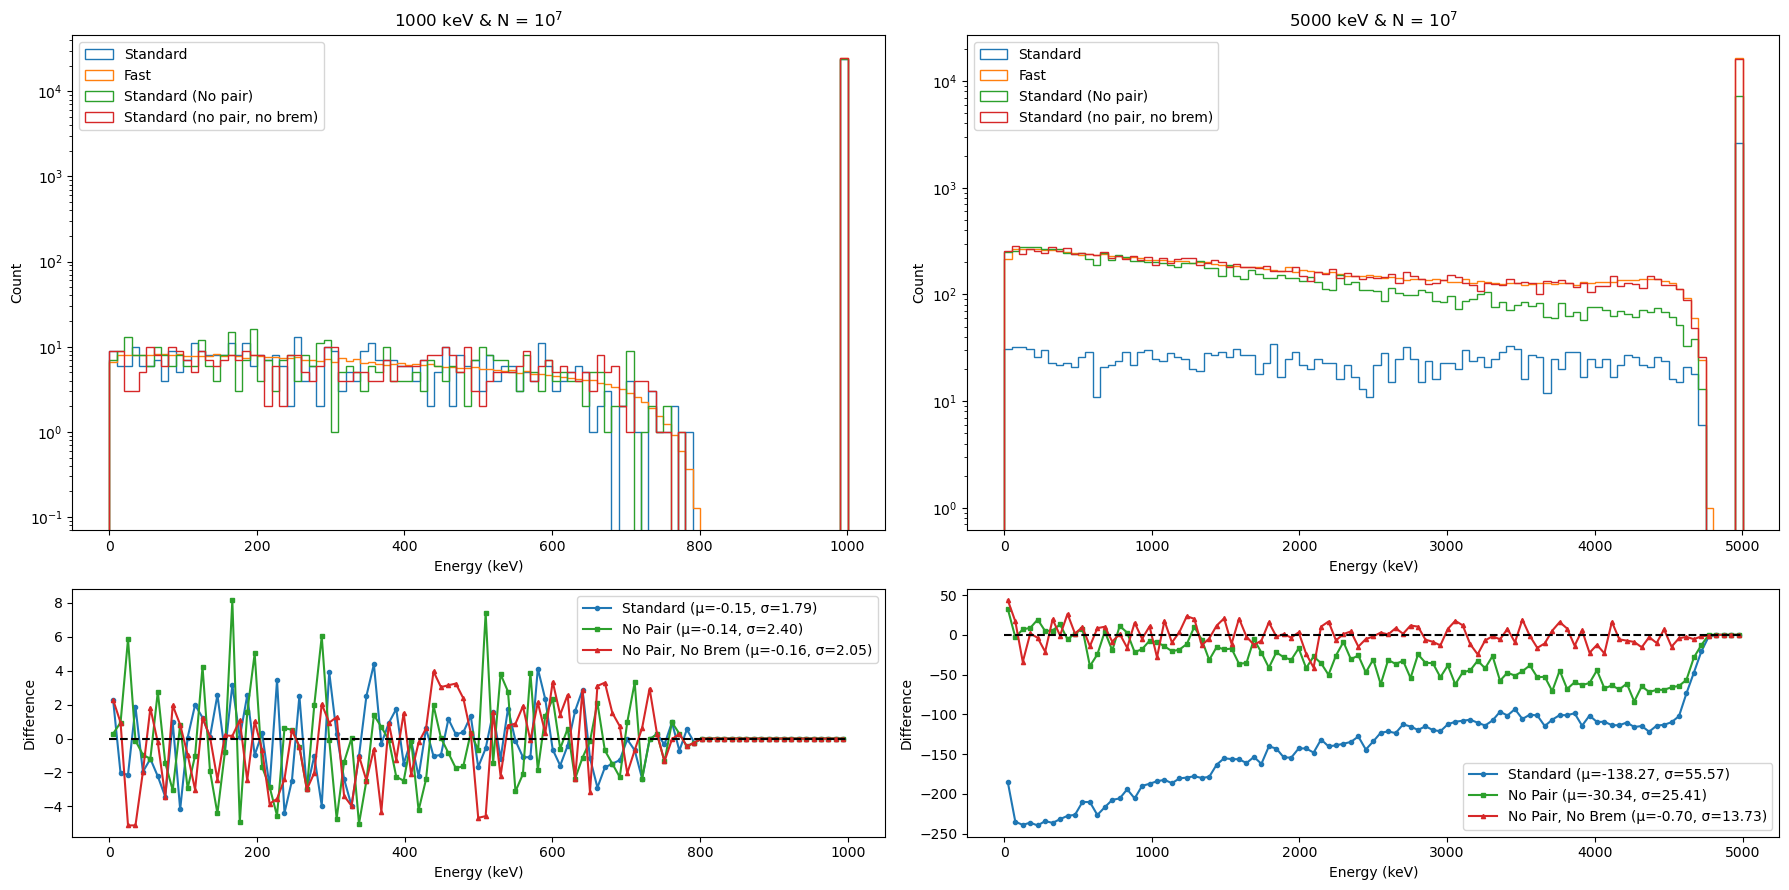

In [27]:
data_sets = {
    1000: [std_1000KeV, fast_1000KeV , std_1000KeV_no_paircr, std_1000KeV_no_paircr_nobrem],
    5000: [std_5000KeV, fast_5000KeV, std_5000KeV_no_paircr, std_5000KeV_no_paircr_nobrem]
}

fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(18, 9),
    gridspec_kw={"height_ratios": [2, 1]}  # Larger height for energy plots
)

axs = axs.reshape(2, 2)  # Reshape to ensure 2 rows, 2 columns

for i, (energy, data_set) in enumerate(data_sets.items()):
    col = i  # Energy and difference plots in the same column

    # Energy plot (top row)
    ax_energy = axs[0, col]
    for data, label in zip(data_set, ["Standard", "Fast", "Standard (No pair)", "Standard (no pair, no brem)", "Standard (no brem)"]):
        data.plot_histogram('eh', ax=ax_energy, bins=100, label=label, show=False, range=(0, energy + 1))

    ax_energy.set_yscale('log')
    ax_energy.set_title(f"{energy} keV & N = $10^7$")
    ax_energy.legend()
    ax_energy.set_xlabel("Energy (keV)")
    ax_energy.set_ylabel("Count")

    # Difference plot (bottom row)
    ax_diff = axs[1, col]
    bins = np.linspace(0, energy - 1, 100)
    
    # Compute histograms
    hist_std, _ = np.histogram(data_set[0].data['eh'], bins=bins)
    hist_fast, _ = np.histogram(data_set[1].data['eh'], bins=bins, weights=np.exp(data_set[1].data['wh']))
    hist_no_pair, _ = np.histogram(data_set[2].data['eh'], bins=bins)
    hist_no_pair_nobrem, _ = np.histogram(data_set[3].data['eh'], bins=bins)

    # Calculate deviations
    abs_diff_fast_std = hist_std - hist_fast
    abs_diff_no_pair_std = hist_no_pair - hist_fast
    abs_diff_no_pair_nobrem_std = hist_no_pair_nobrem - hist_fast

    # Calculate mean and std of deviations
    mean_diff_std = np.mean(abs_diff_fast_std)
    std_diff_std = np.std(abs_diff_fast_std)

    mean_diff_no_pair = np.mean(abs_diff_no_pair_std)
    std_diff_no_pair = np.std(abs_diff_no_pair_std)

    mean_diff_no_pair_nobrem = np.mean(abs_diff_no_pair_nobrem_std)
    std_diff_no_pair_nobrem = np.std(abs_diff_no_pair_nobrem_std)

    # Bin centers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # Plot differences
    ax_diff.plot(bin_centers, abs_diff_fast_std, label=f"Standard (μ={mean_diff_std:.2f}, σ={std_diff_std:.2f})", marker='o', markersize=3, color='tab:blue')
    ax_diff.plot(bin_centers, abs_diff_no_pair_std, label=f"No Pair (μ={mean_diff_no_pair:.2f}, σ={std_diff_no_pair:.2f})", marker='s', markersize=3, color='tab:green')
    ax_diff.plot(bin_centers, abs_diff_no_pair_nobrem_std, label=f"No Pair, No Brem (μ={mean_diff_no_pair_nobrem:.2f}, σ={std_diff_no_pair_nobrem:.2f})", marker='^', markersize=3, color='tab:red')

    ax_diff.hlines(0, xmin=0, xmax=energy, linestyle='--', color='black')
    ax_diff.set_xlabel("Energy (keV)")
    ax_diff.set_ylabel("Difference")
    ax_diff.legend()

# Adjust layout
plt.tight_layout()
plt.savefig("energy_comparison_100m_5k.png")
plt.show()